SALES ANALYTICS DASHBOARD

In [2]:
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT

def create_database():
    # Connection parameters - UPDATE THESE WITH YOUR VALUES
    connection_params = {
        'host': 'localhost',
        'port': 5432,
        'user': 'postgres',
        'password': 'theallfather',
        'database': 'postgres'  # Connect to default database first
    }
    
    # Database name to create - with case preserved
    new_database_name = 'Sql_Dashboard_proj'
    
    try:
        # Connect to PostgreSQL server
        print("Connecting to PostgreSQL...")
        conn = psycopg2.connect(**connection_params)
        conn.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT)
        cursor = conn.cursor()
        
        # Check if database exists - using double quotes for case sensitivity
        # In PostgreSQL, you need to double quote identifiers to preserve case
        cursor.execute('SELECT 1 FROM pg_database WHERE datname = %s', (new_database_name,))
        exists = cursor.fetchone()
        
        if exists:
            print(f"Database '{new_database_name}' already exists.")
        else:
            # Create new database with double quotes to preserve case
            # Use parameterized query with psycopg2.sql to safely quote identifier
            from psycopg2 import sql
            query = sql.SQL("CREATE DATABASE {}").format(
                sql.Identifier(new_database_name)
            )
            cursor.execute(query)
            print(f"Database '{new_database_name}' created successfully with case preserved!")
        
        # Close connection
        cursor.close()
        conn.close()
        
        # Show verification message
        print(f"\nTo connect to this database, use:")
        print(f"Host: localhost")
        print(f"Port: 5432")
        print(f"User: postgres")
        print(f"Database: {new_database_name} (case-sensitive!)")
        print(f"\nNote: When connecting, you might need to use double quotes: \"{new_database_name}\"")
        
    except Exception as e:
        print(f"Error: {e}")

if __name__ == "__main__":
    create_database()

Connecting to PostgreSQL...
Database 'Sql_Dashboard_proj' created successfully with case preserved!

To connect to this database, use:
Host: localhost
Port: 5432
User: postgres
Database: Sql_Dashboard_proj (case-sensitive!)

Note: When connecting, you might need to use double quotes: "Sql_Dashboard_proj"


-- SALES ANALYTICS DATABASE SCHEMA
-- This creates a comprehensive sales database for our dashboard

-- 1. CUSTOMERS TABLE
DROP TABLE IF EXISTS customers CASCADE;
CREATE TABLE customers (
    customer_id SERIAL PRIMARY KEY,
    first_name VARCHAR(50) NOT NULL,
    last_name VARCHAR(50) NOT NULL,
    email VARCHAR(100) UNIQUE NOT NULL,
    phone VARCHAR(20),
    address VARCHAR(200),
    city VARCHAR(50),
    state VARCHAR(50),
    country VARCHAR(50),
    postal_code VARCHAR(20),
    registration_date DATE DEFAULT CURRENT_DATE,
    customer_segment VARCHAR(20) CHECK (customer_segment IN ('Bronze', 'Silver', 'Gold', 'Platinum')),
    is_active BOOLEAN DEFAULT TRUE
);

-- 2. PRODUCTS TABLE
DROP TABLE IF EXISTS products CASCADE;
CREATE TABLE products (
    product_id SERIAL PRIMARY KEY,
    product_name VARCHAR(200) NOT NULL,
    category VARCHAR(50),
    subcategory VARCHAR(50),
    unit_price DECIMAL(10,2) NOT NULL CHECK (unit_price > 0),
    cost_price DECIMAL(10,2) NOT NULL,
    stock_quantity INTEGER DEFAULT 0,
    reorder_level INTEGER DEFAULT 10,
    is_active BOOLEAN DEFAULT TRUE
);

-- 3. ORDERS TABLE
DROP TABLE IF EXISTS orders CASCADE;
CREATE TABLE orders (
    order_id SERIAL PRIMARY KEY,
    customer_id INTEGER REFERENCES customers(customer_id),
    order_date DATE NOT NULL DEFAULT CURRENT_DATE,
    required_date DATE,
    shipped_date DATE,
    status VARCHAR(20) DEFAULT 'Pending' CHECK (status IN ('Pending', 'Processing', 'Shipped', 'Delivered', 'Cancelled')),
    total_amount DECIMAL(10,2) DEFAULT 0,
    shipping_address VARCHAR(200),
    shipping_city VARCHAR(50),
    shipping_country VARCHAR(50)
);

-- 4. ORDER DETAILS TABLE
DROP TABLE IF EXISTS order_details CASCADE;
CREATE TABLE order_details (
    order_detail_id SERIAL PRIMARY KEY,
    order_id INTEGER REFERENCES orders(order_id) ON DELETE CASCADE,
    product_id INTEGER REFERENCES products(product_id),
    quantity INTEGER NOT NULL CHECK (quantity > 0),
    unit_price DECIMAL(10,2) NOT NULL,
    discount DECIMAL(5,2) DEFAULT 0 CHECK (discount >= 0 AND discount <= 100),
    line_total DECIMAL(10,2) GENERATED ALWAYS AS (quantity * unit_price * (1 - discount/100)) STORED
);

-- 5. SALES REPRESENTATIVES TABLE
DROP TABLE IF EXISTS sales_reps CASCADE;
CREATE TABLE sales_reps (
    rep_id SERIAL PRIMARY KEY,
    first_name VARCHAR(50) NOT NULL,
    last_name VARCHAR(50) NOT NULL,
    email VARCHAR(100) UNIQUE NOT NULL,
    region VARCHAR(50),
    hire_date DATE DEFAULT CURRENT_DATE,
    salary DECIMAL(10,2),
    commission_rate DECIMAL(5,2) DEFAULT 0.05
);

-- 6. CUSTOMER-REP ASSIGNMENTS
DROP TABLE IF EXISTS customer_assignments CASCADE;
CREATE TABLE customer_assignments (
    assignment_id SERIAL PRIMARY KEY,
    customer_id INTEGER REFERENCES customers(customer_id),
    rep_id INTEGER REFERENCES sales_reps(rep_id),
    assigned_date DATE DEFAULT CURRENT_DATE,
    is_active BOOLEAN DEFAULT TRUE
);

-- 7. INDEXES FOR PERFORMANCE
CREATE INDEX idx_orders_customer_id ON orders(customer_id);
CREATE INDEX idx_orders_order_date ON orders(order_date);
CREATE INDEX idx_orders_status ON orders(status);
CREATE INDEX idx_order_details_order_id ON order_details(order_id);
CREATE INDEX idx_order_details_product_id ON order_details(product_id);
CREATE INDEX idx_customers_city ON customers(city);
CREATE INDEX idx_customers_country ON customers(country);
CREATE INDEX idx_products_category ON products(category);

COMMENT ON TABLE customers IS 'Stores customer information and demographics';
COMMENT ON TABLE products IS 'Product catalog with pricing and inventory';
COMMENT ON TABLE orders IS 'Sales orders header information';
COMMENT ON TABLE order_details IS 'Individual line items for each order';
COMMENT ON TABLE sales_reps IS 'Sales representatives and their regions';
COMMENT ON TABLE customer_assignments IS 'Mapping of customers to sales reps';

-- INSERT SAMPLE DATA FOR SALES ANALYTICS DASHBOARD

-- 1. Insert customers
INSERT INTO customers (first_name, last_name, email, phone, city, state, country, postal_code, registration_date, customer_segment) VALUES
('James', 'Wilson', 'james.wilson@email.com', '555-0101', 'New York', 'NY', 'USA', '10001', '2023-01-15', 'Platinum'),
('Sarah', 'Johnson', 'sarah.j@email.com', '555-0102', 'Los Angeles', 'CA', 'USA', '90001', '2023-02-20', 'Gold'),
('Michael', 'Brown', 'michael.b@email.com', '555-0103', 'Chicago', 'IL', 'USA', '60601', '2023-03-10', 'Silver'),
('Emily', 'Davis', 'emily.davis@email.com', '555-0104', 'Houston', 'TX', 'USA', '77001', '2023-04-05', 'Gold'),
('Robert', 'Miller', 'robert.m@email.com', '555-0105', 'Phoenix', 'AZ', 'USA', '85001', '2023-05-12', 'Bronze'),
('Jessica', 'Taylor', 'jessica.t@email.com', '555-0106', 'Philadelphia', 'PA', 'USA', '19101', '2023-06-18', 'Silver'),
('David', 'Anderson', 'david.a@email.com', '555-0107', 'San Antonio', 'TX', 'USA', '78201', '2023-07-22', 'Gold'),
('Jennifer', 'Thomas', 'jennifer.t@email.com', '555-0108', 'San Diego', 'CA', 'USA', '92101', '2023-08-30', 'Platinum'),
('William', 'Jackson', 'william.j@email.com', '555-0109', 'Dallas', 'TX', 'USA', '75201', '2023-09-14', 'Silver'),
('Elizabeth', 'White', 'elizabeth.w@email.com', '555-0110', 'San Jose', 'CA', 'USA', '95101', '2023-10-25', 'Gold'),
('John', 'Harris', 'john.h@email.com', '555-0111', 'London', NULL, 'UK', 'SW1A 1AA', '2023-11-05', 'Gold'),
('Maria', 'Martin', 'maria.m@email.com', '555-0112', 'Manchester', NULL, 'UK', 'M1 1AA', '2023-12-10', 'Silver'),
('Charles', 'Thompson', 'charles.t@email.com', '555-0113', 'Toronto', 'ON', 'Canada', 'M5H 2N2', '2024-01-15', 'Platinum'),
('Patricia', 'Garcia', 'patricia.g@email.com', '555-0114', 'Vancouver', 'BC', 'Canada', 'V6C 1A1', '2024-02-20', 'Bronze');

-- 2. Insert products
INSERT INTO products (product_name, category, subcategory, unit_price, cost_price, stock_quantity) VALUES
('MacBook Pro 16"', 'Electronics', 'Laptops', 2499.99, 1800.00, 50),
('iPhone 15 Pro Max', 'Electronics', 'Smartphones', 1199.99, 850.00, 100),
('iPad Air', 'Electronics', 'Tablets', 799.99, 550.00, 75),
('Sony WH-1000XM5', 'Electronics', 'Headphones', 399.99, 250.00, 120),
('Dell UltraSharp 32" Monitor', 'Electronics', 'Monitors', 899.99, 600.00, 40),
('Nike Air Max 270', 'Apparel', 'Shoes', 149.99, 80.00, 200),
('Levi''s 501 Jeans', 'Apparel', 'Clothing', 79.99, 40.00, 150),
('Patagonia Nano Puff Jacket', 'Apparel', 'Outerwear', 229.99, 120.00, 80),
('KitchenAid Stand Mixer', 'Home', 'Kitchen Appliances', 449.99, 280.00, 60),
('Ninja Air Fryer', 'Home', 'Kitchen Appliances', 129.99, 75.00, 90),
('Instant Pot Duo', 'Home', 'Kitchen Appliances', 99.99, 55.00, 110),
('Office Chair Ergonomic', 'Office', 'Furniture', 299.99, 180.00, 70),
('Desk Lamp LED', 'Office', 'Accessories', 49.99, 25.00, 130),
('Wireless Mouse', 'Office', 'Accessories', 29.99, 15.00, 180);

-- 3. Insert sales reps
INSERT INTO sales_reps (first_name, last_name, email, region, hire_date, salary, commission_rate) VALUES
('Alex', 'Rodriguez', 'alex.r@company.com', 'North America East', '2022-03-15', 65000, 0.07),
('Sophia', 'Chen', 'sophia.c@company.com', 'North America West', '2022-06-20', 62000, 0.065),
('Marcus', 'Johnson', 'marcus.j@company.com', 'Europe', '2023-01-10', 58000, 0.06),
('Olivia', 'Williams', 'olivia.w@company.com', 'North America Central', '2023-04-05', 60000, 0.055),
('Daniel', 'Kim', 'daniel.k@company.com', 'Asia Pacific', '2023-09-15', 55000, 0.08);

-- 4. Assign customers to sales reps
INSERT INTO customer_assignments (customer_id, rep_id, assigned_date) VALUES
(1, 1, '2023-01-15'), (2, 2, '2023-02-20'), (3, 4, '2023-03-10'), (4, 4, '2023-04-05'),
(5, 2, '2023-05-12'), (6, 1, '2023-06-18'), (7, 4, '2023-07-22'), (8, 2, '2023-08-30'),
(9, 4, '2023-09-14'), (10, 2, '2023-10-25'), (11, 3, '2023-11-05'), (12, 3, '2023-12-10'),
(13, 1, '2024-01-15'), (14, 5, '2024-02-20');

-- 5. Insert orders (generated with realistic dates and amounts)
INSERT INTO orders (customer_id, order_date, required_date, shipped_date, status, shipping_city, shipping_country) VALUES
(1, '2024-01-10', '2024-01-17', '2024-01-12', 'Delivered', 'New York', 'USA'),
(1, '2024-02-15', '2024-02-22', '2024-02-18', 'Delivered', 'New York', 'USA'),
(2, '2024-01-12', '2024-01-19', '2024-01-15', 'Delivered', 'Los Angeles', 'USA'),
(3, '2024-01-20', '2024-01-27', '2024-01-25', 'Delivered', 'Chicago', 'USA'),
(4, '2024-02-05', '2024-02-12', '2024-02-10', 'Delivered', 'Houston', 'USA'),
(5, '2024-02-18', '2024-02-25', '2024-02-22', 'Delivered', 'Phoenix', 'USA'),
(6, '2024-02-28', '2024-03-06', '2024-03-04', 'Delivered', 'Philadelphia', 'USA'),
(7, '2024-03-10', '2024-03-17', '2024-03-15', 'Delivered', 'San Antonio', 'USA'),
(8, '2024-03-15', '2024-03-22', '2024-03-20', 'Delivered', 'San Diego', 'USA'),
(9, '2024-03-20', '2024-03-27', '2024-03-25', 'Delivered', 'Dallas', 'USA'),
(10, '2024-03-25', '2024-04-01', '2024-03-30', 'Delivered', 'San Jose', 'USA'),
(11, '2024-03-28', '2024-04-04', '2024-04-02', 'Delivered', 'London', 'UK'),
(12, '2024-04-01', '2024-04-08', '2024-04-06', 'Delivered', 'Manchester', 'UK'),
(13, '2024-04-05', '2024-04-12', '2024-04-10', 'Delivered', 'Toronto', 'Canada'),
(14, '2024-04-10', '2024-04-17', NULL, 'Processing', 'Vancouver', 'Canada');

-- 6. Insert order details
INSERT INTO order_details (order_id, product_id, quantity, unit_price, discount) VALUES
(1, 1, 1, 2499.99, 0), (1, 4, 1, 399.99, 10),
(2, 3, 2, 799.99, 5), (2, 13, 1, 49.99, 0),
(3, 2, 1, 1199.99, 0), (3, 6, 1, 149.99, 15),
(4, 5, 1, 899.99, 0), (4, 12, 1, 299.99, 5),
(5, 7, 3, 79.99, 20), (5, 8, 1, 229.99, 10),
(6, 9, 1, 449.99, 0), (6, 10, 1, 129.99, 0),
(7, 11, 2, 99.99, 10), (7, 14, 1, 29.99, 0),
(8, 1, 1, 2499.99, 15), (8, 4, 2, 399.99, 5),
(9, 3, 1, 799.99, 0), (9, 6, 1, 149.99, 0),
(10, 7, 2, 79.99, 10), (10, 8, 1, 229.99, 0),
(11, 9, 1, 449.99, 5), (11, 11, 1, 99.99, 0),
(12, 2, 1, 1199.99, 0), (12, 5, 1, 899.99, 10),
(13, 1, 1, 2499.99, 0), (13, 3, 1, 799.99, 0),
(14, 4, 1, 399.99, 0), (14, 6, 2, 149.99, 15);

-- 7. Update order totals based on order details
UPDATE orders o
SET total_amount = (
    SELECT COALESCE(SUM(od.line_total), 0)
    FROM order_details od
    WHERE od.order_id = o.order_id
)
WHERE total_amount = 0;

-- Verify data insertion
SELECT 'Customers' as table_name, COUNT(*) as row_count FROM customers
UNION ALL SELECT 'Products', COUNT(*) FROM products
UNION ALL SELECT 'Sales Reps', COUNT(*) FROM sales_reps
UNION ALL SELECT 'Orders', COUNT(*) FROM orders
UNION ALL SELECT 'Order Details', COUNT(*) FROM order_details;

In [2]:
# In terminal or notebook cell
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy psycopg2-binary jinja2
!pip install nbformat>=4.2.0 plotly

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
# Force Jupyter notebook mode for Plotly
import plotly.io as pio
pio.renderers.default = "notebook"

# Or try these alternatives:
# pio.renderers.default = "jupyterlab"
# pio.renderers.default = "png"  # Render as static image
# pio.renderers.default = "svg"  # Render as SVG


# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# %%
# Database connection setup
# Update these credentials with your actual database info
DB_CONFIG = {
    'username': 'postgres',
    'password': 'theallfather',  # Your password here
    'host': 'localhost',
    'port': '5432',
    'database': 'Sql_Dashboard_proj'   # Your database name
}

# Create connection string
conn_string = f"postgresql://{DB_CONFIG['username']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

# Create SQLAlchemy engine
engine = create_engine(conn_string)

# Test connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version()"))
        db_version = result.fetchone()[0]
    print(f"✅ Connected to: {db_version}")
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Please check your database credentials and make sure the database exists.")

✅ Connected to: PostgreSQL 16.11 (Ubuntu 16.11-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu, compiled by gcc (Ubuntu 13.3.0-6ubuntu2~24.04) 13.3.0, 64-bit


In [4]:
# ## 2. Helper Functions

# %%
def run_sql_query(query, params=None):
    """
    Execute SQL query and return results as DataFrame
    """
    try:
        if params:
            df = pd.read_sql(query, engine, params=params)
        else:
            df = pd.read_sql(query, engine)
        
        print(f"✅ Query executed successfully. Returned {len(df)} rows.")
        return df
    except Exception as e:
        print(f"❌ Query failed: {e}")
        return pd.DataFrame()

def format_currency(value):
    """Format number as currency"""
    try:
        return f"${value:,.2f}"
    except:
        return f"${value}"

def format_percentage(value):
    """Format number as percentage"""
    try:
        return f"{value:.1f}%"
    except:
        return f"{value}%"

def display_dataframe(df, title=None, max_rows=10):
    """Display DataFrame with nice formatting"""
    if title:
        print(f"\n{title}")
        print("-" * min(50, len(title)))
    
    if len(df) > max_rows:
        print(f"Showing top {max_rows} of {len(df)} rows:")
        print(df.head(max_rows).to_string(index=False))
    else:
        print(df.to_string(index=False))
    
    print()


📈 GENERATING EXECUTIVE SUMMARY REPORT...
✅ Query executed successfully. Returned 1 rows.

📊 EXECUTIVE SUMMARY
----------------------------------------

                  Metric      Value
         Total Customers         14
   Customers with Orders         14
Customer Conversion Rate     100.0%
            Total Orders         15
        Completed Orders         14
   Order Completion Rate     93.33%
          Total Products         14
           Products Sold         14
       Sell-Through Rate     100.0%
           Total Revenue $37,665.32
            Gross Profit $24,934.33
            Gross Margin      66.2%
     Average Order Value  $1,298.80
       Days of Operation         91
      Avg Orders per Day       0.16

📊 CREATING VISUALIZATIONS...


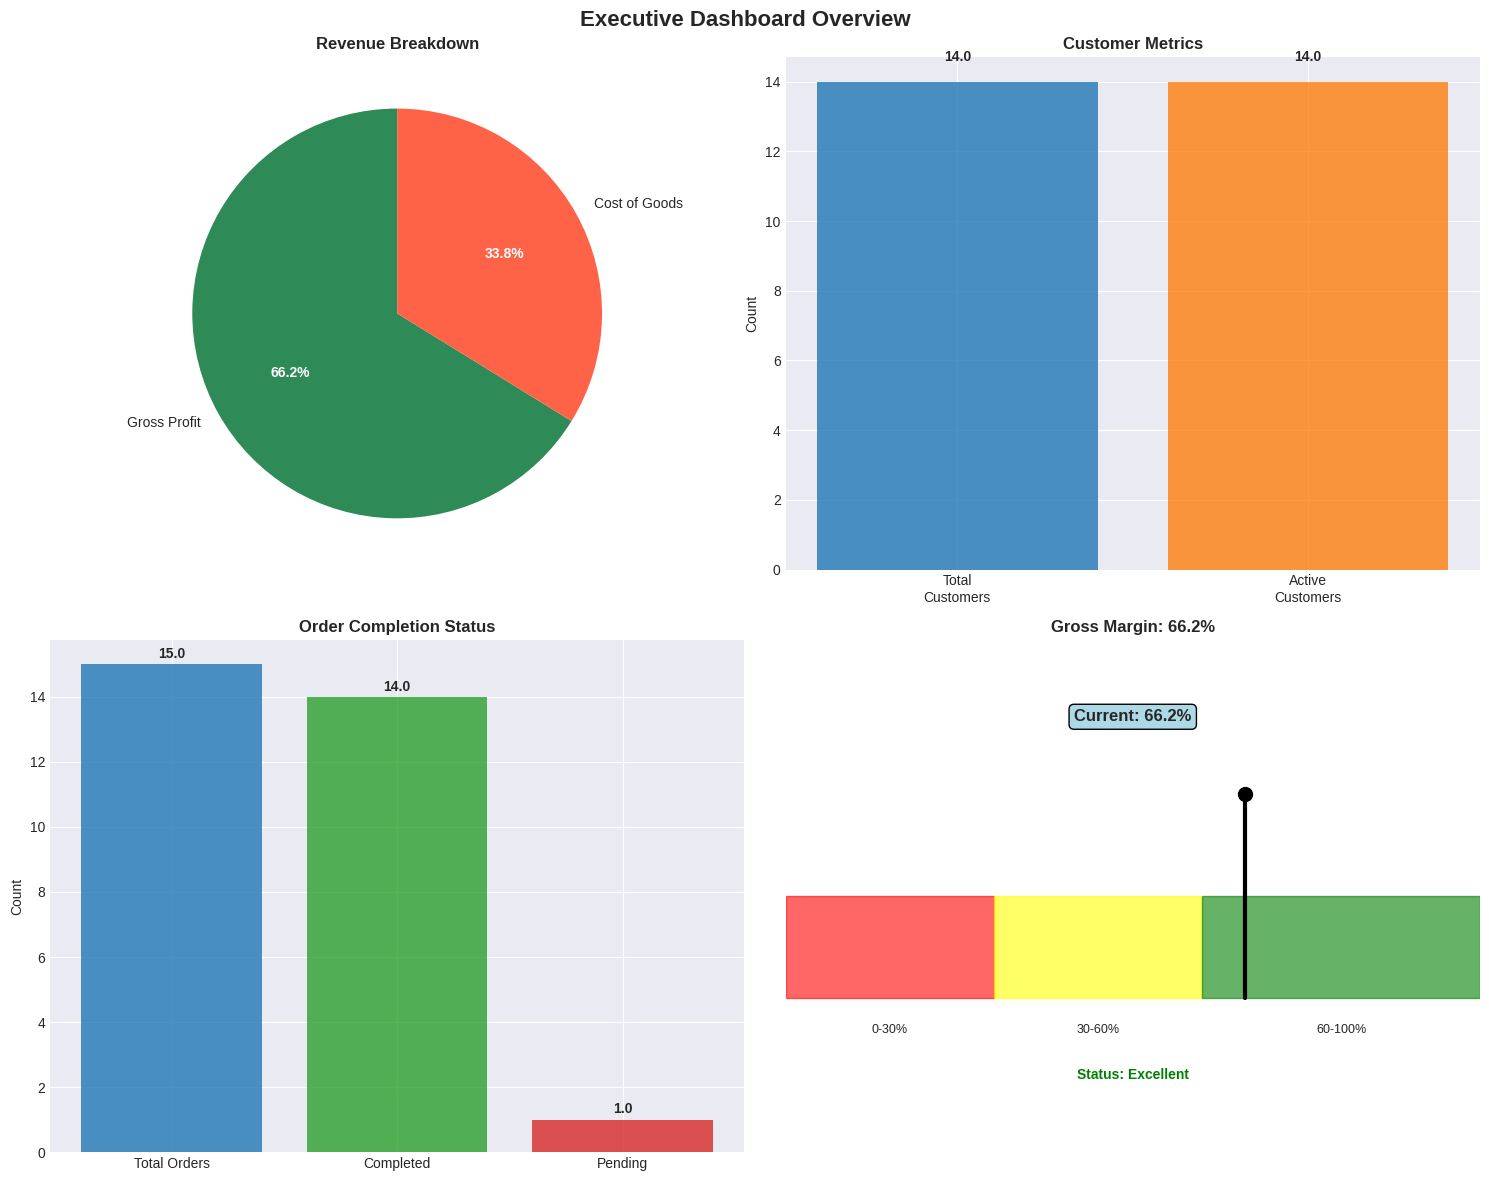

✅ Visualization saved as 'dashboard_exports/executive_summary.png'


In [5]:
# %%time
# Report 1: Executive Summary
print("📈 GENERATING EXECUTIVE SUMMARY REPORT...")
print("=" * 50)

executive_query = """
WITH executive_metrics AS (
    SELECT 
        -- Customer metrics
        COUNT(DISTINCT c.customer_id) AS total_customers,
        COUNT(DISTINCT o.customer_id) AS customers_with_orders,
        
        -- Order metrics
        COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(DISTINCT CASE WHEN o.status = 'Delivered' THEN o.order_id END) AS completed_orders,
        
        -- Product metrics
        COUNT(DISTINCT p.product_id) AS total_products,
        COUNT(DISTINCT od.product_id) AS products_sold,
        
        -- Financial metrics
        COALESCE(SUM(CASE WHEN o.status IN ('Delivered', 'Processing') THEN o.total_amount END), 0) AS total_revenue,
        COALESCE(SUM(CASE WHEN o.status IN ('Delivered', 'Processing') THEN od.line_total * (p.cost_price / p.unit_price) END), 0) AS total_cost,
        COALESCE(AVG(CASE WHEN o.status IN ('Delivered', 'Processing') THEN o.total_amount END), 0) AS avg_order_value,
        
        -- Date metrics
        MIN(o.order_date) AS first_order_date,
        MAX(o.order_date) AS last_order_date
        
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id
    LEFT JOIN order_details od ON o.order_id = od.order_id
    LEFT JOIN products p ON od.product_id = p.product_id
)
SELECT 
    -- Customer insights
    total_customers,
    customers_with_orders,
    ROUND((customers_with_orders::NUMERIC / NULLIF(total_customers, 0)) * 100, 2) AS customer_conversion_rate_pct,
    
    -- Order insights
    total_orders,
    completed_orders,
    ROUND((completed_orders::NUMERIC / NULLIF(total_orders, 0)) * 100, 2) AS order_completion_rate_pct,
    
    -- Product insights
    total_products,
    products_sold,
    ROUND((products_sold::NUMERIC / NULLIF(total_products, 0)) * 100, 2) AS product_sell_through_pct,
    
    -- Financial insights
    ROUND(total_revenue, 2) AS total_revenue,
    ROUND(total_cost, 2) AS total_cost,
    ROUND(total_revenue - total_cost, 2) AS gross_profit,
    ROUND(((total_revenue - total_cost) / NULLIF(total_revenue, 0)) * 100, 2) AS gross_margin_pct,
    ROUND(avg_order_value, 2) AS avg_order_value,
    
    -- Time insights - FIXED: Direct date subtraction instead of EXTRACT
    COALESCE(last_order_date - first_order_date, 0) AS days_of_operation,
    CASE 
        WHEN COALESCE(last_order_date - first_order_date, 0) = 0 THEN 0
        ELSE ROUND(total_orders::NUMERIC / (last_order_date - first_order_date + 1), 2)
    END AS avg_orders_per_day
    
FROM executive_metrics
"""

df_executive = run_sql_query(executive_query)

# Display Executive Summary
print("\n📊 EXECUTIVE SUMMARY")
print("-" * 40)

if not df_executive.empty:
    metrics = df_executive.iloc[0]
    
    # Create a nice display
    summary_data = {
        "Metric": [
            "Total Customers",
            "Customers with Orders",
            "Customer Conversion Rate",
            "Total Orders",
            "Completed Orders",
            "Order Completion Rate",
            "Total Products",
            "Products Sold",
            "Sell-Through Rate",
            "Total Revenue",
            "Gross Profit",
            "Gross Margin",
            "Average Order Value",
            "Days of Operation",
            "Avg Orders per Day"
        ],
        "Value": [
            f"{int(metrics['total_customers']):,}",
            f"{int(metrics['customers_with_orders']):,}",
            f"{metrics['customer_conversion_rate_pct']}%",
            f"{int(metrics['total_orders']):,}",
            f"{int(metrics['completed_orders']):,}",
            f"{metrics['order_completion_rate_pct']}%",
            f"{int(metrics['total_products']):,}",
            f"{int(metrics['products_sold']):,}",
            f"{metrics['product_sell_through_pct']}%",
            format_currency(metrics['total_revenue']),
            format_currency(metrics['gross_profit']),
            format_percentage(metrics['gross_margin_pct']),
            format_currency(metrics['avg_order_value']),
            f"{int(metrics['days_of_operation']):,}",
            f"{metrics['avg_orders_per_day']}"
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + summary_df.to_string(index=False))
    
    # VISUALIZATIONS WITH MATPLOTLIB (NO PLOTLY)
    print("\n📊 CREATING VISUALIZATIONS...")
    
    # Create a 2x2 grid of subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Executive Dashboard Overview', fontsize=16, fontweight='bold')
    
    # 1. Revenue Breakdown (Pie Chart)
    revenue_labels = ['Gross Profit', 'Cost of Goods']
    revenue_values = [metrics['gross_profit'], metrics['total_cost']]
    colors1 = ['#2E8B57', '#FF6347']
    wedges1, texts1, autotexts1 = axes[0, 0].pie(revenue_values, labels=revenue_labels, 
                                                autopct='%1.1f%%', colors=colors1,
                                                startangle=90)
    axes[0, 0].set_title('Revenue Breakdown', fontweight='bold')
    
    # Make labels more visible
    for autotext in autotexts1:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    # 2. Customer Metrics (Bar Chart)
    customer_labels = ['Total\nCustomers', 'Active\nCustomers']
    customer_values = [metrics['total_customers'], metrics['customers_with_orders']]
    bars = axes[0, 1].bar(customer_labels, customer_values, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    axes[0, 1].set_title('Customer Metrics', fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    
    # Add value labels on bars
    for bar, value in zip(bars, customer_values):
        height = bar.get_height()
        axes[0, 1].text(bar.get_x() + bar.get_width()/2, height + 0.5,
                       f'{value:,}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Order Completion Status (Bar Chart)
    order_labels = ['Total Orders', 'Completed', 'Pending']
    order_values = [
        metrics['total_orders'],
        metrics['completed_orders'],
        metrics['total_orders'] - metrics['completed_orders']
    ]
    colors3 = ['#1f77b4', '#2ca02c', '#d62728']
    bars2 = axes[1, 0].bar(order_labels, order_values, color=colors3, alpha=0.8)
    axes[1, 0].set_title('Order Completion Status', fontweight='bold')
    axes[1, 0].set_ylabel('Count')
    
    # Add value labels on bars
    for bar, value in zip(bars2, order_values):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, height + 0.1,
                       f'{value:,}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Gross Margin Gauge (Custom Visualization)
    margin = metrics['gross_margin_pct']
    ax = axes[1, 1]
    
    # Draw gauge background
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Gross Margin: {margin:.1f}%', fontweight='bold')
    
    # Draw colored segments
    colors_gauge = ['red', 'yellow', 'green']
    ranges = [(0, 30), (30, 60), (60, 100)]
    
    for i, (start, end) in enumerate(ranges):
        ax.add_patch(plt.Rectangle((start, 0.3), end-start, 0.2, 
                                   color=colors_gauge[i], alpha=0.6))
    
    # Draw needle
    needle_x = margin
    ax.plot([needle_x, needle_x], [0.3, 0.7], 'k-', linewidth=3)
    ax.plot(needle_x, 0.7, 'ko', markersize=10)
    
    # Add range labels
    for start, end in ranges:
        ax.text((start + end) / 2, 0.25, f'{start}-{end}%', 
                ha='center', va='top', fontsize=9)
    
    # Add current value
    ax.text(50, 0.85, f'Current: {margin:.1f}%', 
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    # Add performance indicator
    if margin >= 60:
        status = "Excellent"
        status_color = "green"
    elif margin >= 30:
        status = "Good"
        status_color = "orange"
    else:
        status = "Needs Improvement"
        status_color = "red"
    
    ax.text(50, 0.15, f'Status: {status}', 
            ha='center', va='center', fontsize=10, fontweight='bold',
            color=status_color)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    import os
    os.makedirs('dashboard_exports', exist_ok=True)
    fig.savefig('dashboard_exports/executive_summary.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/executive_summary.png'")
    
else:
    print("No data found for executive summary.")

Report 2: Top Performing Products


📦 GENERATING TOP PRODUCTS REPORT...
✅ Query executed successfully. Returned 14 rows.

📊 TOP 10 PERFORMING PRODUCTS
--------------------------------------------------

Top 10 Products by Revenue
--------------------------
               product_name    category unit_price  total_quantity_sold total_revenue profit_margin_pct inventory_status
            MacBook Pro 16" Electronics  $2,499.99                    3     $7,124.97            24.21%          Healthy
                   iPad Air Electronics    $799.99                    4     $3,119.96            29.49%          Healthy
          iPhone 15 Pro Max Electronics  $1,199.99                    2     $2,399.98            29.17%          Healthy
Dell UltraSharp 32" Monitor Electronics    $899.99                    2     $1,709.98            29.82%          Healthy
            Sony WH-1000XM5 Electronics    $399.99                    4     $1,519.96            34.21%          Healthy
     KitchenAid Stand Mixer        Home    $449.99  

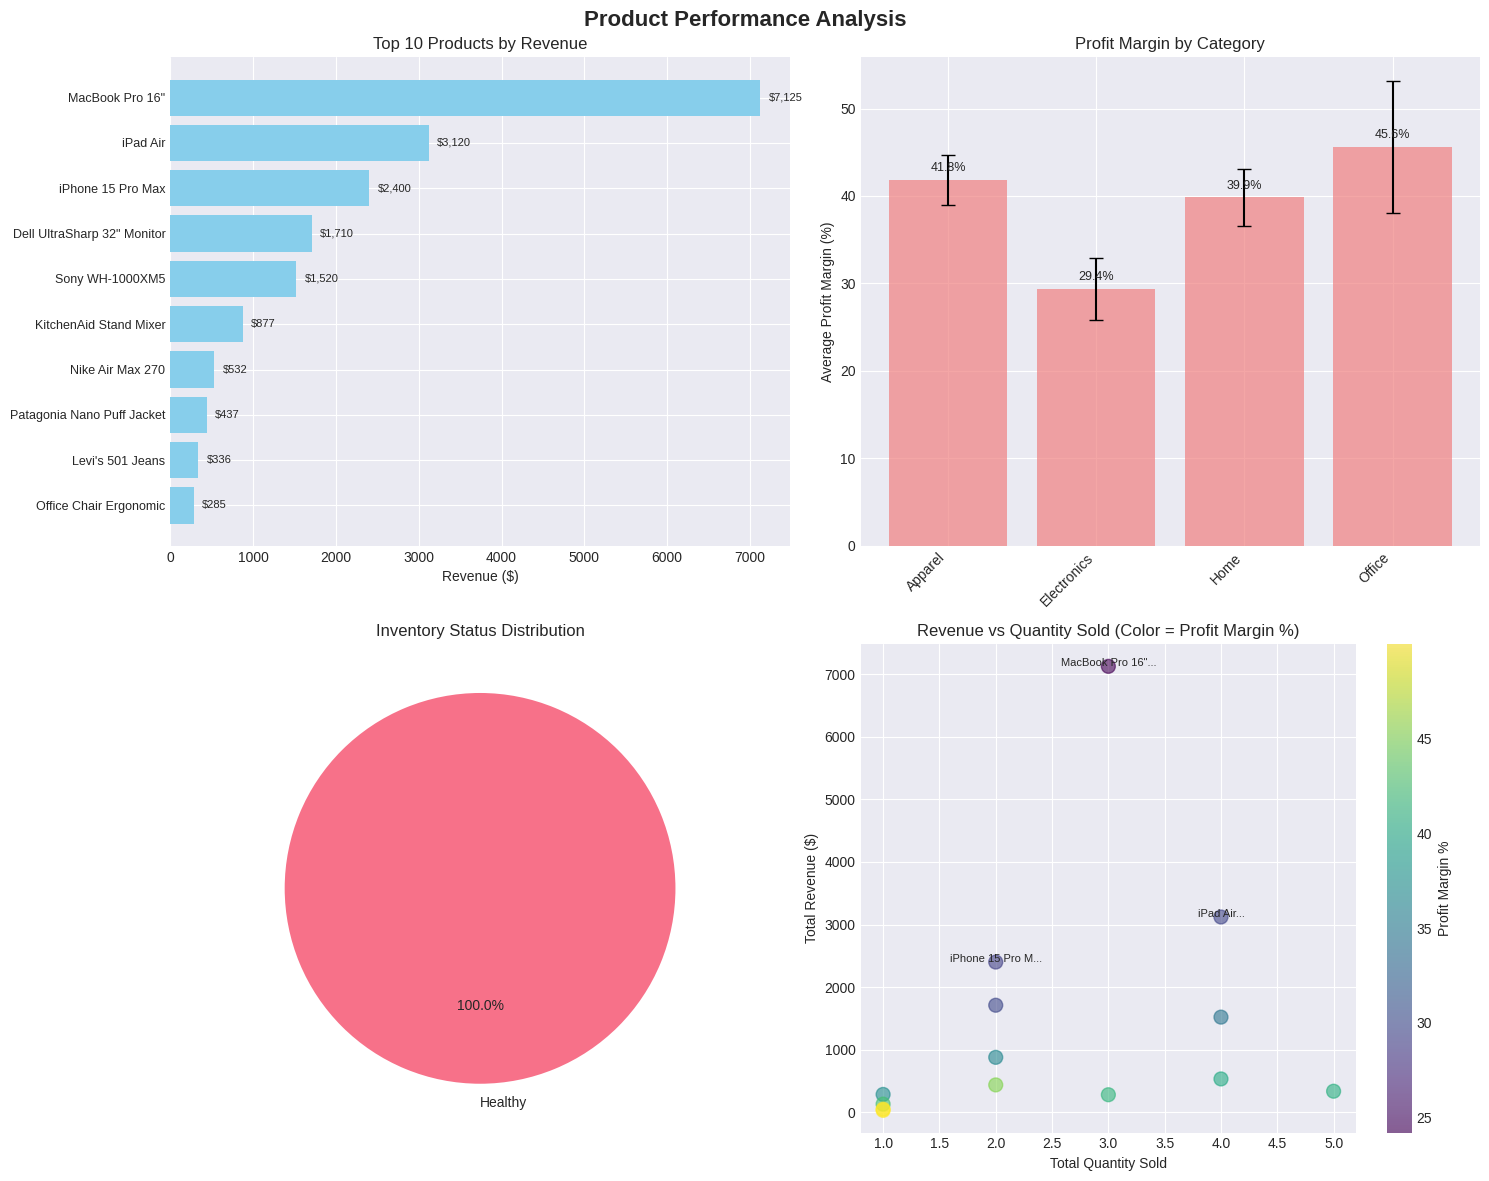

✅ Visualization saved as 'dashboard_exports/product_performance.png'

👥 GENERATING CUSTOMER RFM ANALYSIS...
✅ Query executed successfully. Returned 14 rows.

📊 CUSTOMER RFM SEGMENTATION ANALYSIS
----------------------------------------

Top 10 Customers by Lifetime Value
----------------------------------
   customer_name customer_segment        city lifetime_value      rfm_segment engagement_priority
    James Wilson         Platinum    New York      $4,429.95 Recent Customers        Low Priority
    Maria Martin           Silver  Manchester      $3,299.98          At Risk        Low Priority
  David Anderson             Gold San Antonio      $2,884.97  Loyal Customers       High Priority
     John Harris             Gold      London      $2,009.98          At Risk        Low Priority
   Sarah Johnson             Gold Los Angeles      $1,327.48 Recent Customers        Low Priority
   Michael Brown           Silver     Chicago      $1,184.98 Recent Customers        Low Priority
 Jennif

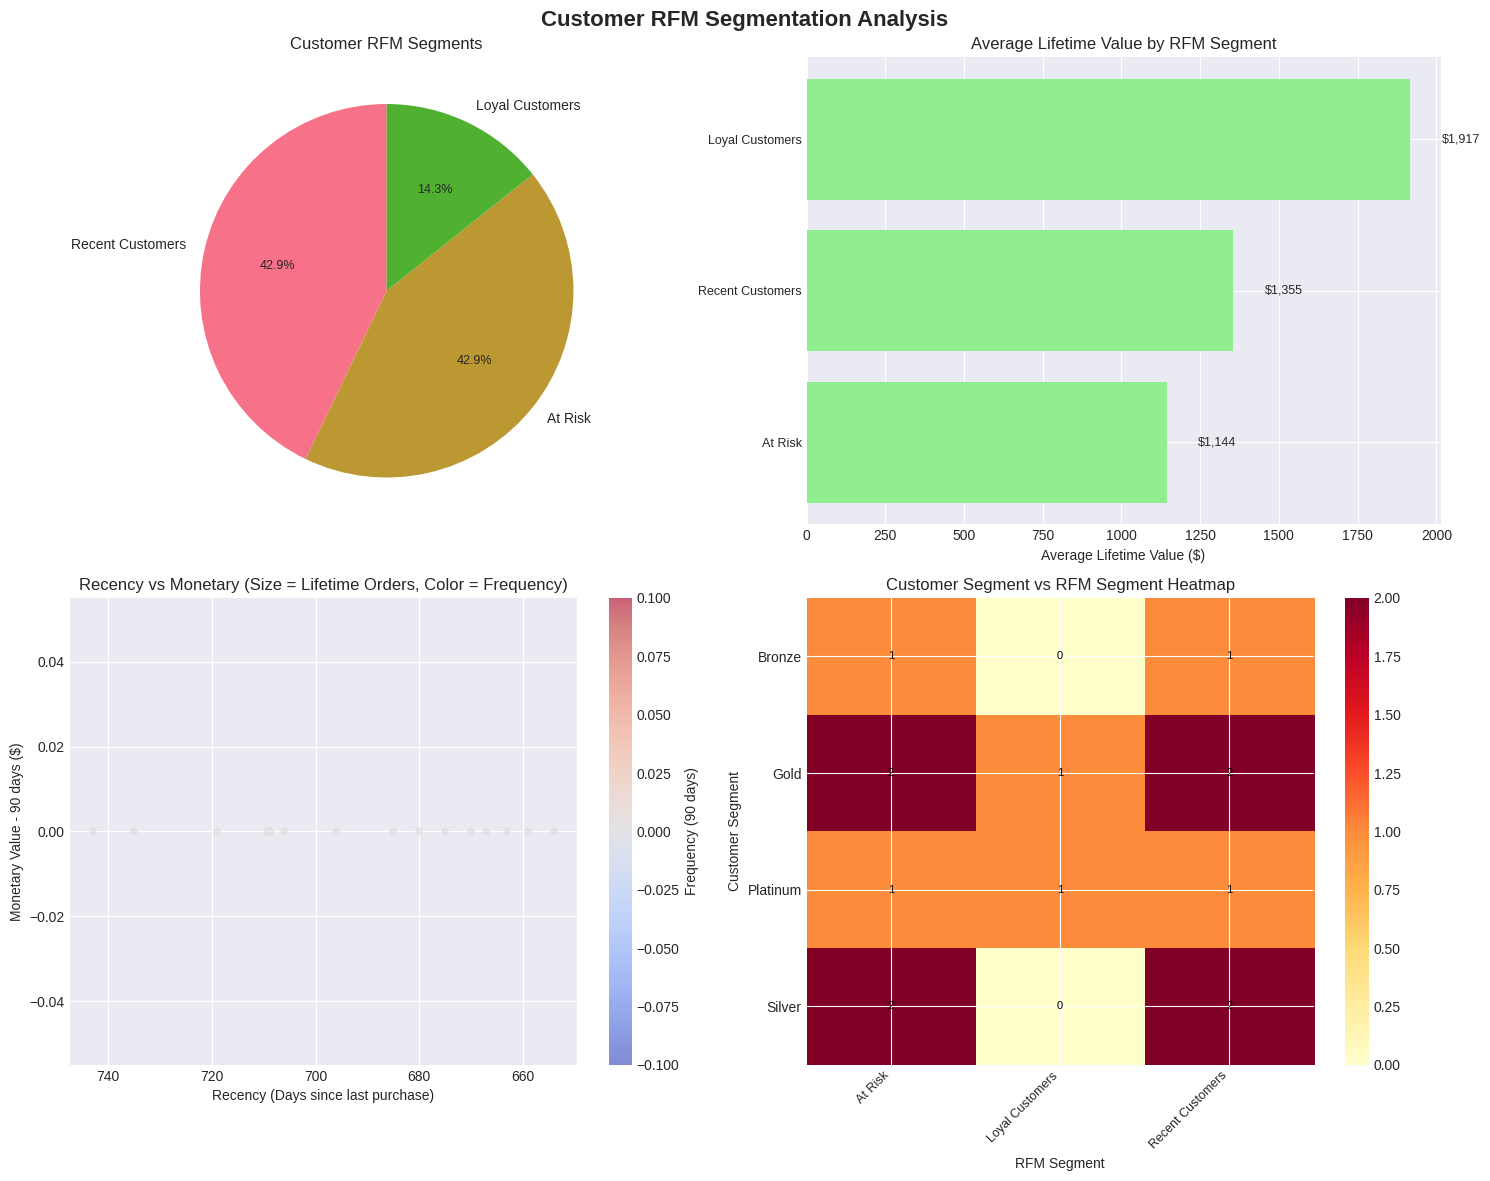

✅ Visualization saved as 'dashboard_exports/customer_rfm.png'

📋 RFM SEGMENT SUMMARY:
------------------------------

At Risk:
  • Customers: 6
  • Avg Lifetime Value: $1,144.40
  • Total Value: $6,866.38
  • Avg Recency: 665 days

Loyal Customers:
  • Customers: 2
  • Avg Lifetime Value: $1,917.48
  • Total Value: $3,834.95
  • Avg Recency: 682 days

Recent Customers:
  • Customers: 6
  • Avg Lifetime Value: $1,355.22
  • Total Value: $8,131.33
  • Avg Recency: 718 days


In [8]:
# %% [markdown]
# ## 4. Report 2: Top Performing Products

# %%
# %%time
# Report 2: Top Performing Products
print("\n📦 GENERATING TOP PRODUCTS REPORT...")
print("=" * 50)

products_query = """
WITH product_performance AS (
    SELECT 
        p.product_id,
        p.product_name,
        p.category,
        p.subcategory,
        p.unit_price,
        p.cost_price,
        p.stock_quantity,
        p.reorder_level,
        
        -- Sales metrics
        COALESCE(SUM(od.quantity), 0) AS total_quantity_sold,
        COALESCE(COUNT(DISTINCT o.order_id), 0) AS times_ordered,
        COALESCE(SUM(od.line_total), 0) AS total_revenue,
        
        -- Cost and profit metrics
        COALESCE(SUM(od.quantity * p.cost_price), 0) AS total_cost,
        COALESCE(SUM(od.line_total - (od.quantity * p.cost_price)), 0) AS total_profit
        
    FROM products p
    LEFT JOIN order_details od ON p.product_id = od.product_id
    LEFT JOIN orders o ON od.order_id = o.order_id AND o.status IN ('Delivered', 'Processing')
    GROUP BY p.product_id, p.product_name, p.category, p.subcategory, p.unit_price, p.cost_price, p.stock_quantity, p.reorder_level
)
SELECT 
    product_name,
    category,
    subcategory,
    ROUND(unit_price, 2) AS unit_price,
    total_quantity_sold,
    ROUND(total_revenue, 2) AS total_revenue,
    ROUND(total_profit, 2) AS total_profit,
    ROUND((total_profit / NULLIF(total_revenue, 0)) * 100, 2) AS profit_margin_pct,
    stock_quantity,
    reorder_level,
    CASE 
        WHEN stock_quantity <= reorder_level THEN 'Reorder Needed'
        WHEN stock_quantity <= reorder_level * 2 THEN 'Low Stock'
        WHEN total_quantity_sold = 0 THEN 'No Sales'
        ELSE 'Healthy'
    END AS inventory_status,
    ROUND(total_revenue / NULLIF(times_ordered, 0), 2) AS avg_revenue_per_order
    
FROM product_performance
ORDER BY total_revenue DESC
"""

df_products = run_sql_query(products_query)

# Display Top Products
print(f"\n📊 TOP {min(10, len(df_products))} PERFORMING PRODUCTS")
print("-" * 50)

if not df_products.empty:
    # Display top 10 products
    top_products = df_products.head(10).copy()
    top_products['unit_price'] = top_products['unit_price'].apply(format_currency)
    top_products['total_revenue'] = top_products['total_revenue'].apply(format_currency)
    top_products['total_profit'] = top_products['total_profit'].apply(format_currency)
    top_products['profit_margin_pct'] = top_products['profit_margin_pct'].apply(lambda x: f"{x}%")
    top_products['avg_revenue_per_order'] = top_products['avg_revenue_per_order'].apply(format_currency)
    
    display_cols = ['product_name', 'category', 'unit_price', 'total_quantity_sold', 
                    'total_revenue', 'profit_margin_pct', 'inventory_status']
    display_dataframe(top_products[display_cols], "Top 10 Products by Revenue")
    
    # VISUALIZATION 2: Product Performance
    print("📊 CREATING PRODUCT PERFORMANCE VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Product Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Top 10 Products by Revenue (Horizontal Bar Chart)
    top_10_products = df_products.head(10)
    y_pos = np.arange(len(top_10_products))
    axes[0, 0].barh(y_pos, top_10_products['total_revenue'], color='skyblue')
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels(top_10_products['product_name'], fontsize=9)
    axes[0, 0].set_xlabel('Revenue ($)')
    axes[0, 0].set_title('Top 10 Products by Revenue')
    axes[0, 0].invert_yaxis()
    
    for i, v in enumerate(top_10_products['total_revenue']):
        axes[0, 0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=8)
    
    # 2. Profit Margin by Category
    margin_by_category = df_products.groupby('category')['profit_margin_pct'].agg(['mean', 'std', 'count']).reset_index()
    x_pos = np.arange(len(margin_by_category))
    axes[0, 1].bar(x_pos, margin_by_category['mean'], 
                   yerr=margin_by_category['std'], capsize=5, color='lightcoral', alpha=0.7)
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(margin_by_category['category'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('Average Profit Margin (%)')
    axes[0, 1].set_title('Profit Margin by Category')
    
    for i, v in enumerate(margin_by_category['mean']):
        axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
    
    # 3. Inventory Status Distribution
    inventory_counts = df_products['inventory_status'].value_counts()
    wedges, texts, autotexts = axes[1, 0].pie(inventory_counts.values, 
                                              labels=inventory_counts.index, 
                                              autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Inventory Status Distribution')
    
    # 4. Revenue vs Quantity Sold (Scatter Plot)
    scatter = axes[1, 1].scatter(df_products['total_quantity_sold'], 
                                 df_products['total_revenue'],
                                 c=df_products['profit_margin_pct'], 
                                 cmap='viridis', s=100, alpha=0.6)
    axes[1, 1].set_xlabel('Total Quantity Sold')
    axes[1, 1].set_ylabel('Total Revenue ($)')
    axes[1, 1].set_title('Revenue vs Quantity Sold (Color = Profit Margin %)')
    plt.colorbar(scatter, ax=axes[1, 1], label='Profit Margin %')
    
    # Annotate top 3 products
    for i, row in df_products.head(3).iterrows():
        axes[1, 1].annotate(row['product_name'][:15] + '...', 
                           (row['total_quantity_sold'], row['total_revenue']),
                           fontsize=8, ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    fig.savefig('dashboard_exports/product_performance.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/product_performance.png'")
    
else:
    print("No product data found.")

# %% [markdown]
# ## 5. Report 3: Customer RFM Analysis

# %%
# %%time
# Report 3: Customer RFM Analysis
print("\n👥 GENERATING CUSTOMER RFM ANALYSIS...")
print("=" * 50)

rfm_query = """
WITH customer_rfm AS (
    SELECT 
        c.customer_id,
        c.first_name || ' ' || c.last_name AS customer_name,
        c.customer_segment,
        c.city,
        c.country,
        c.registration_date,
        
        -- Recency: Days since last purchase - SIMPLE FIX: Cast to integer
        COALESCE((CURRENT_DATE - MAX(o.order_date))::INTEGER, 365) AS recency_days,
        
        -- Frequency: Number of purchases in last 90 days
        COALESCE(COUNT(DISTINCT CASE 
            WHEN o.order_date >= CURRENT_DATE - INTERVAL '90 days' 
            THEN o.order_id 
        END), 0) AS frequency_90d,
        
        -- Monetary: Total spent in last 90 days
        COALESCE(SUM(CASE 
            WHEN o.order_date >= CURRENT_DATE - INTERVAL '90 days' 
            THEN o.total_amount 
        END), 0) AS monetary_90d,
        
        -- Lifetime value
        COALESCE(COUNT(DISTINCT o.order_id), 0) AS lifetime_orders,
        COALESCE(SUM(o.total_amount), 0) AS lifetime_value
        
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.status IN ('Delivered', 'Processing')
    GROUP BY c.customer_id, c.first_name, c.last_name, c.customer_segment, c.city, c.country, c.registration_date
),
rfm_scores AS (
    SELECT 
        *,
        -- Score Recency (lower days = better)
        NTILE(5) OVER (ORDER BY recency_days ASC) AS recency_score,
        
        -- Score Frequency (higher frequency = better)
        NTILE(5) OVER (ORDER BY frequency_90d DESC) AS frequency_score,
        
        -- Score Monetary (higher monetary = better)
        NTILE(5) OVER (ORDER BY monetary_90d DESC) AS monetary_score
    FROM customer_rfm
),
rfm_segments AS (
    SELECT 
        *,
        recency_score * 100 + frequency_score * 10 + monetary_score AS rfm_cell,
        CASE 
            WHEN recency_score >= 4 AND frequency_score >= 4 AND monetary_score >= 4 THEN 'Champions'
            WHEN recency_score >= 3 AND frequency_score >= 3 THEN 'Loyal Customers'
            WHEN recency_score >= 3 AND monetary_score >= 3 THEN 'Potential Loyalists'
            WHEN recency_score >= 3 AND frequency_score <= 2 THEN 'Recent Customers'
            WHEN recency_score <= 2 AND frequency_score >= 3 THEN 'At Risk'
            WHEN recency_score <= 2 AND frequency_score <= 2 AND monetary_score >= 3 THEN 'Cant Lose Them'
            WHEN recency_score <= 2 AND monetary_score <= 2 THEN 'Hibernating'
            ELSE 'Need Attention'
        END AS rfm_segment
    FROM rfm_scores
)
SELECT 
    customer_name,
    customer_segment,
    city,
    country,
    registration_date,
    recency_days,
    frequency_90d,
    ROUND(monetary_90d, 2) AS monetary_90d,
    lifetime_orders,
    ROUND(lifetime_value, 2) AS lifetime_value,
    recency_score,
    frequency_score,
    monetary_score,
    rfm_cell,
    rfm_segment,
    CASE 
        WHEN rfm_segment IN ('Champions', 'Loyal Customers') THEN 'High Priority'
        WHEN rfm_segment IN ('Potential Loyalists', 'Cant Lose Them') THEN 'Medium Priority'
        ELSE 'Low Priority'
    END AS engagement_priority
    
FROM rfm_segments
ORDER BY lifetime_value DESC
"""


df_rfm = run_sql_query(rfm_query)

# Display RFM Analysis
print("\n📊 CUSTOMER RFM SEGMENTATION ANALYSIS")
print("-" * 40)

if not df_rfm.empty:
    # Display top customers by lifetime value
    top_customers = df_rfm.head(10).copy()
    top_customers['monetary_90d'] = top_customers['monetary_90d'].apply(format_currency)
    top_customers['lifetime_value'] = top_customers['lifetime_value'].apply(format_currency)
    
    display_cols = ['customer_name', 'customer_segment', 'city', 'lifetime_value', 
                    'rfm_segment', 'engagement_priority']
    display_dataframe(top_customers[display_cols], "Top 10 Customers by Lifetime Value")
    
    # VISUALIZATION 3: RFM Analysis
    print("📊 CREATING CUSTOMER RFM VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Customer RFM Segmentation Analysis', fontsize=16, fontweight='bold')
    
    # 1. RFM Segment Distribution
    segment_counts = df_rfm['rfm_segment'].value_counts()
    wedges1, texts1, autotexts1 = axes[0, 0].pie(segment_counts.values, 
                                                  labels=segment_counts.index, 
                                                  autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('Customer RFM Segments')
    for autotext in autotexts1:
        autotext.set_fontsize(9)
    
    # 2. Lifetime Value by Segment
    segment_value = df_rfm.groupby('rfm_segment')['lifetime_value'].mean().sort_values()
    y_pos = np.arange(len(segment_value))
    bars = axes[0, 1].barh(y_pos, segment_value.values, color='lightgreen')
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(segment_value.index, fontsize=9)
    axes[0, 1].set_xlabel('Average Lifetime Value ($)')
    axes[0, 1].set_title('Average Lifetime Value by RFM Segment')
    
    for i, v in enumerate(segment_value.values):
        axes[0, 1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)
    
    # 3. Recency vs Monetary Scatter
    scatter = axes[1, 0].scatter(df_rfm['recency_days'], df_rfm['monetary_90d'],
                                 c=df_rfm['frequency_90d'], cmap='coolwarm', 
                                 s=df_rfm['lifetime_orders']*20, alpha=0.6)
    axes[1, 0].set_xlabel('Recency (Days since last purchase)')
    axes[1, 0].set_ylabel('Monetary Value - 90 days ($)')
    axes[1, 0].set_title('Recency vs Monetary (Size = Lifetime Orders, Color = Frequency)')
    plt.colorbar(scatter, ax=axes[1, 0], label='Frequency (90 days)')
    axes[1, 0].invert_xaxis()  # Lower recency is better
    
    # 4. Customer Segment vs RFM Segment Heatmap
    cross_tab = pd.crosstab(df_rfm['customer_segment'], df_rfm['rfm_segment'])
    im = axes[1, 1].imshow(cross_tab.values, cmap='YlOrRd', aspect='auto')
    axes[1, 1].set_xticks(range(len(cross_tab.columns)))
    axes[1, 1].set_xticklabels(cross_tab.columns, rotation=45, ha='right', fontsize=9)
    axes[1, 1].set_yticks(range(len(cross_tab.index)))
    axes[1, 1].set_yticklabels(cross_tab.index)
    axes[1, 1].set_xlabel('RFM Segment')
    axes[1, 1].set_ylabel('Customer Segment')
    axes[1, 1].set_title('Customer Segment vs RFM Segment Heatmap')
    
    for i in range(len(cross_tab.index)):
        for j in range(len(cross_tab.columns)):
            axes[1, 1].text(j, i, cross_tab.iloc[i, j], 
                           ha='center', va='center', color='black', fontsize=8)
    
    plt.colorbar(im, ax=axes[1, 1])
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    fig.savefig('dashboard_exports/customer_rfm.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/customer_rfm.png'")
    
    # Customer segmentation summary
    print("\n📋 RFM SEGMENT SUMMARY:")
    print("-" * 30)
    segment_summary = df_rfm.groupby('rfm_segment').agg({
        'customer_name': 'count',
        'lifetime_value': ['mean', 'sum'],
        'recency_days': 'mean'
    }).round(2)
    
    segment_summary.columns = ['Customer Count', 'Avg Lifetime Value', 'Total Lifetime Value', 'Avg Recency Days']
    
    # Display summary
    for segment, data in segment_summary.iterrows():
        print(f"\n{segment}:")
        print(f"  • Customers: {int(data['Customer Count'])}")
        print(f"  • Avg Lifetime Value: {format_currency(data['Avg Lifetime Value'])}")
        print(f"  • Total Value: {format_currency(data['Total Lifetime Value'])}")
        print(f"  • Avg Recency: {data['Avg Recency Days']:.0f} days")
    
else:
    print("No customer data found for RFM analysis.")

Report 4: Sales Trends Analysis


📈 GENERATING SALES TRENDS ANALYSIS...
✅ Query executed successfully. Returned 4 rows.

📊 SALES TREND ANALYSIS
----------------------------------------

Monthly Sales Trends
--------------------
 period month_name  sales_year  sales_month_num  order_count  customer_count total_revenue avg_order_value  total_quantity_sold
2024-01  January        2024.0              1.0            3               3    $10,744.88       $1,790.81                    6
2024-02  February       2024.0              2.0            4               4     $5,517.78         $689.72                   12
2024-03  March          2024.0              3.0            5               5    $13,492.76       $1,349.28                   12
2024-04  April          2024.0              4.0            2               2     $7,909.90       $1,977.48                    5

📊 CREATING SALES TRENDS VISUALIZATIONS...


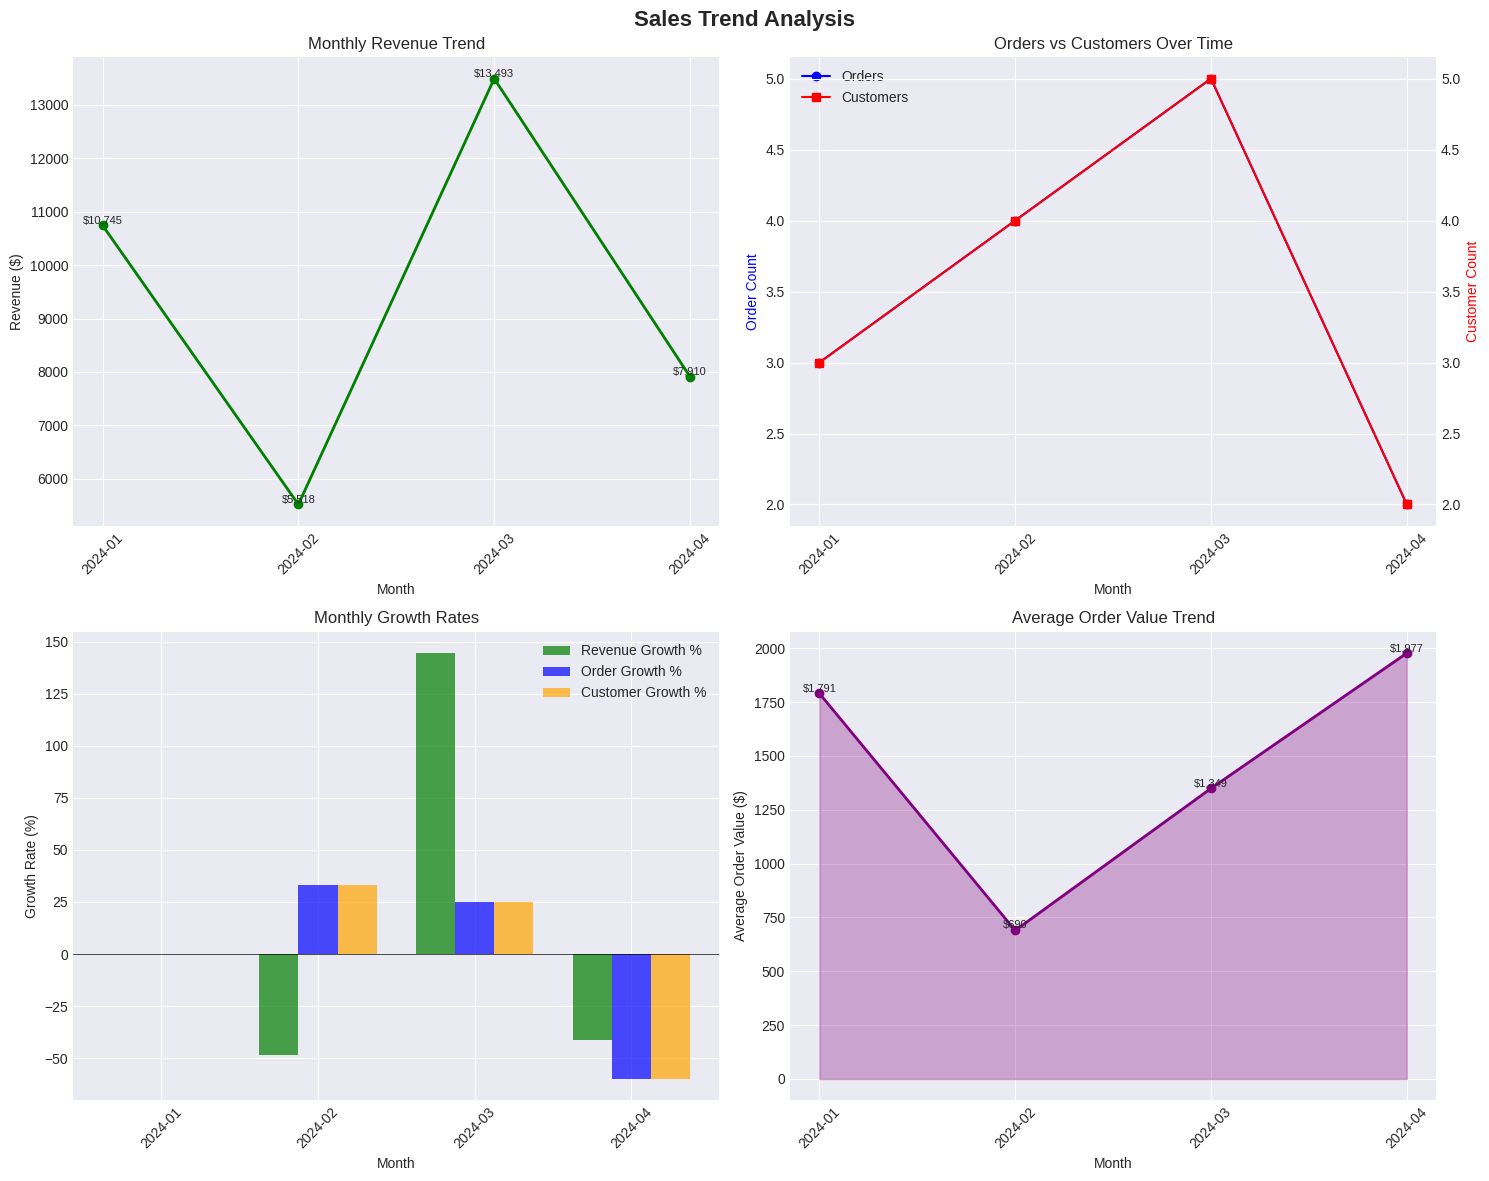

✅ Visualization saved as 'dashboard_exports/sales_trends.png'

📈 KEY TREND INSIGHTS:
------------------------------
• Latest Month (2024-04): Revenue: $7,909.90, Orders: 2
• Month-over-Month Revenue Growth: -41.4%
• Month-over-Month Order Growth: -60.0%
• Average Order Value Trend: ↑ Increasing
• Best Performing Month: 2024-03 (Revenue: $13,492.76)

🌎 GENERATING GEOGRAPHIC PERFORMANCE REPORT...
✅ Query executed successfully. Returned 14 rows.

📊 GEOGRAPHIC PERFORMANCE ANALYSIS
----------------------------------------

Top 10 Locations by Revenue
---------------------------
country state        city  total_customers  total_orders total_revenue  conversion_rate_pct revenue_pct_of_total
    USA    NY    New York                1             2     $4,429.95                100.0                23.5%
     UK  None  Manchester                1             1     $3,299.98                100.0                17.5%
    USA    TX San Antonio                1             1     $2,884.97           

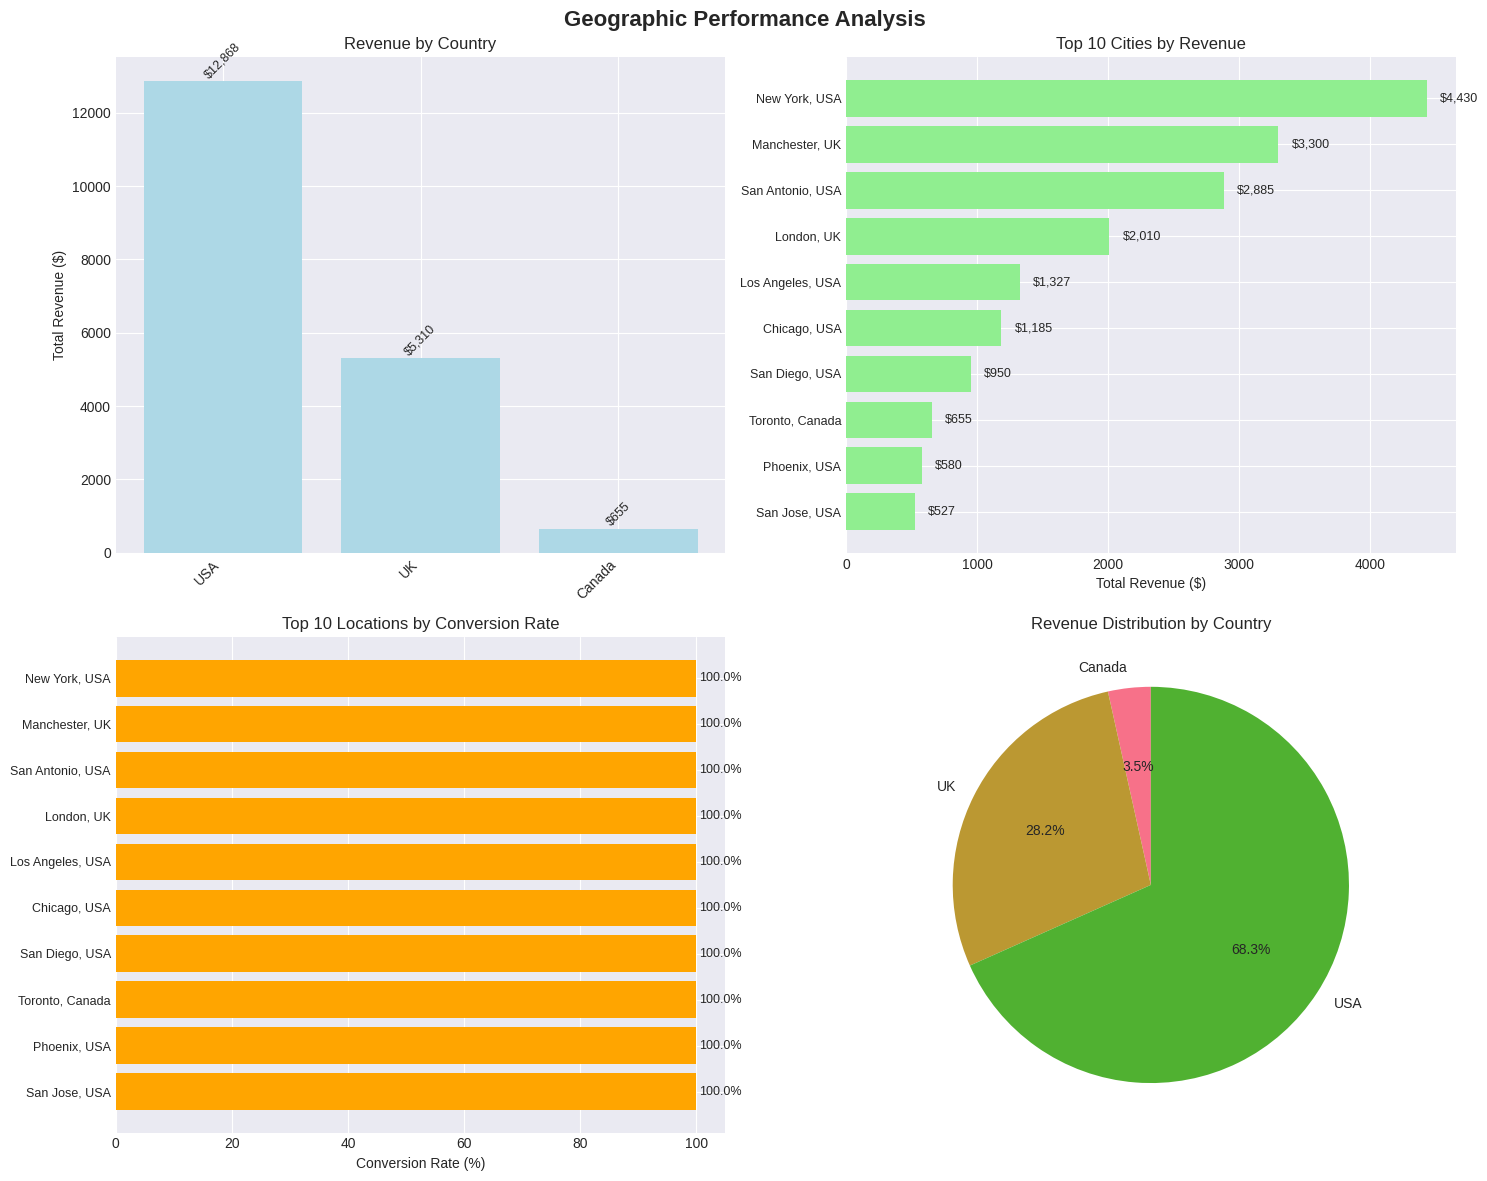

✅ Visualization saved as 'dashboard_exports/geographic_performance.png'

🌍 GEOGRAPHIC INSIGHTS:
------------------------------
• Top Performing Country: USA (Revenue: $4,429.95)
• Highest Conversion Rate: New York, USA (100.0%)
• Highest Average Order Value: Manchester, UK ($3,299.98)
• Total Countries with Sales: 3
• Total Cities with Sales: 14


In [9]:
# 6. Report 4: Sales Trends Analysis

# %%
# %%time
# Report 4: Sales Trends Analysis
print("\n📈 GENERATING SALES TRENDS ANALYSIS...")
print("=" * 50)

trends_query = """
WITH monthly_sales AS (
    SELECT 
        DATE_TRUNC('month', o.order_date) AS sales_month,
        EXTRACT(YEAR FROM o.order_date) AS sales_year,
        EXTRACT(MONTH FROM o.order_date) AS sales_month_num,
        TO_CHAR(o.order_date, 'Month') AS month_name,
        
        -- Key metrics
        COUNT(DISTINCT o.order_id) AS order_count,
        COUNT(DISTINCT o.customer_id) AS customer_count,
        SUM(o.total_amount) AS total_revenue,
        AVG(o.total_amount) AS avg_order_value,
        SUM(od.quantity) AS total_quantity_sold
        
    FROM orders o
    JOIN order_details od ON o.order_id = od.order_id
    JOIN products p ON od.product_id = p.product_id
    WHERE o.status IN ('Delivered', 'Processing')
    GROUP BY DATE_TRUNC('month', o.order_date), EXTRACT(YEAR FROM o.order_date), 
             EXTRACT(MONTH FROM o.order_date), TO_CHAR(o.order_date, 'Month')
)
SELECT 
    TO_CHAR(sales_month, 'YYYY-MM') AS period,
    month_name,
    sales_year,
    sales_month_num,
    
    -- Current month metrics
    order_count,
    customer_count,
    ROUND(total_revenue, 2) AS total_revenue,
    ROUND(avg_order_value, 2) AS avg_order_value,
    total_quantity_sold
    
FROM monthly_sales
ORDER BY sales_month
"""

df_trends = run_sql_query(trends_query)

# Display Sales Trends
print("\n📊 SALES TREND ANALYSIS")
print("-" * 40)

if not df_trends.empty:
    # Display trend data
    display_df = df_trends.copy()
    display_df['total_revenue'] = display_df['total_revenue'].apply(format_currency)
    display_df['avg_order_value'] = display_df['avg_order_value'].apply(format_currency)
    display_dataframe(display_df, "Monthly Sales Trends")
    
    # Calculate growth rates
    df_trends['revenue_growth'] = df_trends['total_revenue'].pct_change() * 100
    df_trends['order_growth'] = df_trends['order_count'].pct_change() * 100
    df_trends['customer_growth'] = df_trends['customer_count'].pct_change() * 100
    
    # VISUALIZATION 4: Sales Trends
    print("📊 CREATING SALES TRENDS VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Sales Trend Analysis', fontsize=16, fontweight='bold')
    
    # 1. Revenue Trend Line Chart
    axes[0, 0].plot(df_trends['period'], df_trends['total_revenue'], 
                   marker='o', linewidth=2, color='green')
    axes[0, 0].set_xlabel('Month')
    axes[0, 0].set_ylabel('Revenue ($)')
    axes[0, 0].set_title('Monthly Revenue Trend')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(df_trends['total_revenue']):
        axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Order and Customer Growth (Dual Axis)
    ax2 = axes[0, 1].twinx()
    line1 = axes[0, 1].plot(df_trends['period'], df_trends['order_count'], 
                           marker='o', color='blue', label='Orders')
    line2 = ax2.plot(df_trends['period'], df_trends['customer_count'], 
                    marker='s', color='red', label='Customers')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Order Count', color='blue')
    ax2.set_ylabel('Customer Count', color='red')
    axes[0, 1].set_title('Orders vs Customers Over Time')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    axes[0, 1].legend(lines, labels, loc='upper left')
    
    # 3. Growth Rates (Grouped Bar Chart)
    x = np.arange(len(df_trends))
    width = 0.25
    axes[1, 0].bar(x - width, df_trends['revenue_growth'].fillna(0), 
                  width, label='Revenue Growth %', color='green', alpha=0.7)
    axes[1, 0].bar(x, df_trends['order_growth'].fillna(0), 
                  width, label='Order Growth %', color='blue', alpha=0.7)
    axes[1, 0].bar(x + width, df_trends['customer_growth'].fillna(0), 
                  width, label='Customer Growth %', color='orange', alpha=0.7)
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Growth Rate (%)')
    axes[1, 0].set_title('Monthly Growth Rates')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(df_trends['period'], rotation=45)
    axes[1, 0].legend()
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    
    # 4. Average Order Value Trend
    axes[1, 1].plot(df_trends['period'], df_trends['avg_order_value'], 
                   marker='o', linewidth=2, color='purple')
    axes[1, 1].fill_between(df_trends['period'], df_trends['avg_order_value'], 
                           alpha=0.3, color='purple')
    axes[1, 1].set_xlabel('Month')
    axes[1, 1].set_ylabel('Average Order Value ($)')
    axes[1, 1].set_title('Average Order Value Trend')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    for i, v in enumerate(df_trends['avg_order_value']):
        axes[1, 1].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    fig.savefig('dashboard_exports/sales_trends.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/sales_trends.png'")
    
    # Calculate and display key insights
    print("\n📈 KEY TREND INSIGHTS:")
    print("-" * 30)
    
    if len(df_trends) > 1:
        latest = df_trends.iloc[-1]
        previous = df_trends.iloc[-2]
        
        insights = [
            f"• Latest Month ({latest['period']}): Revenue: {format_currency(latest['total_revenue'])}, Orders: {latest['order_count']}",
            f"• Month-over-Month Revenue Growth: {latest['revenue_growth']:.1f}%",
            f"• Month-over-Month Order Growth: {latest['order_growth']:.1f}%",
            f"• Average Order Value Trend: {'↑ Increasing' if latest['avg_order_value'] > previous['avg_order_value'] else '↓ Decreasing'}",
            f"• Best Performing Month: {df_trends.loc[df_trends['total_revenue'].idxmax(), 'period']} (Revenue: {format_currency(df_trends['total_revenue'].max())})"
        ]
        
        for insight in insights:
            print(insight)
    
else:
    print("No trend data found.")

# %% [markdown]
# ## 7. Report 5: Geographic Performance

# %%
# %%time
# Report 5: Geographic Performance
print("\n🌎 GENERATING GEOGRAPHIC PERFORMANCE REPORT...")
print("=" * 50)

geo_query = """
WITH geographic_sales AS (
    SELECT 
        COALESCE(o.shipping_country, c.country) AS country,
        COALESCE(o.shipping_city, c.city) AS city,
        c.state,
        
        -- Customer metrics
        COUNT(DISTINCT c.customer_id) AS total_customers,
        COUNT(DISTINCT o.customer_id) AS customers_with_orders,
        
        -- Order metrics
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(o.total_amount) AS total_revenue,
        AVG(o.total_amount) AS avg_order_value
        
    FROM customers c
    LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.status IN ('Delivered', 'Processing')
    WHERE COALESCE(o.shipping_country, c.country) IS NOT NULL
    GROUP BY COALESCE(o.shipping_country, c.country), COALESCE(o.shipping_city, c.city), c.state
)
SELECT 
    country,
    state,
    city,
    
    -- Customer metrics
    total_customers,
    customers_with_orders,
    ROUND((customers_with_orders::NUMERIC / NULLIF(total_customers, 0)) * 100, 2) AS conversion_rate_pct,
    
    -- Order metrics
    total_orders,
    ROUND(total_revenue, 2) AS total_revenue,
    ROUND(avg_order_value, 2) AS avg_order_value,
    total_revenue / NULLIF(SUM(total_revenue) OVER (), 0) * 100 AS revenue_pct_of_total
    
FROM geographic_sales
ORDER BY total_revenue DESC
"""

df_geo = run_sql_query(geo_query)

# Display Geographic Performance
print("\n📊 GEOGRAPHIC PERFORMANCE ANALYSIS")
print("-" * 40)

if not df_geo.empty:
    # Display top locations
    top_locations = df_geo.head(10).copy()
    top_locations['total_revenue'] = top_locations['total_revenue'].apply(format_currency)
    top_locations['avg_order_value'] = top_locations['avg_order_value'].apply(format_currency)
    top_locations['revenue_pct_of_total'] = top_locations['revenue_pct_of_total'].apply(lambda x: f"{x:.1f}%")
    
    display_cols = ['country', 'state', 'city', 'total_customers', 'total_orders', 
                    'total_revenue', 'conversion_rate_pct', 'revenue_pct_of_total']
    display_dataframe(top_locations[display_cols], "Top 10 Locations by Revenue")
    
    # VISUALIZATION 5: Geographic Performance
    print("📊 CREATING GEOGRAPHIC PERFORMANCE VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Geographic Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Revenue by Country
    country_revenue = df_geo.groupby('country')['total_revenue'].sum().sort_values(ascending=False)
    bars1 = axes[0, 0].bar(range(len(country_revenue)), country_revenue.values, color='lightblue')
    axes[0, 0].set_xticks(range(len(country_revenue)))
    axes[0, 0].set_xticklabels(country_revenue.index, rotation=45, ha='right')
    axes[0, 0].set_ylabel('Total Revenue ($)')
    axes[0, 0].set_title('Revenue by Country')
    
    for i, v in enumerate(country_revenue.values):
        axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9, rotation=45)
    
    # 2. Top 10 Cities by Revenue
    top_cities = df_geo.nlargest(10, 'total_revenue')
    y_pos = np.arange(len(top_cities))
    bars2 = axes[0, 1].barh(y_pos, top_cities['total_revenue'], color='lightgreen')
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(top_cities['city'] + ', ' + top_cities['country'], fontsize=9)
    axes[0, 1].set_xlabel('Total Revenue ($)')
    axes[0, 1].set_title('Top 10 Cities by Revenue')
    axes[0, 1].invert_yaxis()
    
    for i, v in enumerate(top_cities['total_revenue']):
        axes[0, 1].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)
    
    # 3. Conversion Rate by Location
    top_conversion = df_geo.nlargest(10, 'conversion_rate_pct')
    y_pos2 = np.arange(len(top_conversion))
    bars3 = axes[1, 0].barh(y_pos2, top_conversion['conversion_rate_pct'], color='orange')
    axes[1, 0].set_yticks(y_pos2)
    axes[1, 0].set_yticklabels(top_conversion['city'] + ', ' + top_conversion['country'], fontsize=9)
    axes[1, 0].set_xlabel('Conversion Rate (%)')
    axes[1, 0].set_title('Top 10 Locations by Conversion Rate')
    axes[1, 0].invert_yaxis()
    
    for i, v in enumerate(top_conversion['conversion_rate_pct']):
        axes[1, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    
    # 4. Revenue Distribution Pie Chart
    country_dist = df_geo.groupby('country')['total_revenue'].sum()
    wedges, texts, autotexts = axes[1, 1].pie(country_dist.values, 
                                               labels=country_dist.index, 
                                               autopct='%1.1f%%', startangle=90)
    axes[1, 1].set_title('Revenue Distribution by Country')
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    fig.savefig('dashboard_exports/geographic_performance.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/geographic_performance.png'")
    
    # Summary statistics
    print("\n🌍 GEOGRAPHIC INSIGHTS:")
    print("-" * 30)
    
    top_country = df_geo.loc[df_geo['total_revenue'].idxmax()]
    highest_conversion = df_geo.nlargest(1, 'conversion_rate_pct').iloc[0]
    highest_avg_order = df_geo.nlargest(1, 'avg_order_value').iloc[0]
    
    insights = [
        f"• Top Performing Country: {top_country['country']} (Revenue: {format_currency(top_country['total_revenue'])})",
        f"• Highest Conversion Rate: {highest_conversion['city']}, {highest_conversion['country']} ({highest_conversion['conversion_rate_pct']}%)",
        f"• Highest Average Order Value: {highest_avg_order['city']}, {highest_avg_order['country']} ({format_currency(highest_avg_order['avg_order_value'])})",
        f"• Total Countries with Sales: {df_geo['country'].nunique()}",
        f"• Total Cities with Sales: {df_geo['city'].nunique()}"
    ]
    
    for insight in insights:
        print(insight)
    
else:
    print("No geographic data found.")


# 8. Report 6: Sales Rep Performance


👨‍💼 GENERATING SALES REP PERFORMANCE REPORT...
✅ Query executed successfully. Returned 5 rows.

📊 SALES REPRESENTATIVE PERFORMANCE
----------------------------------------

Sales Representative Performance
--------------------------------
       rep_name                region  tenure_months  assigned_customers  active_customers customer_activation_rate_pct total_sales  performance_vs_region_avg sales_per_month
 Marcus Johnson                Europe           36.0                   2                 2                       100.0%   $5,309.96                        1.0         $147.50
 Alex Rodriguez    North America East           46.0                   3                 3                       100.0%   $5,294.89                        1.0         $115.11
Olivia Williams North America Central           33.0                   4                 4                       100.0%   $4,842.89                        1.0         $146.75
    Sophia Chen    North America West           43.0        

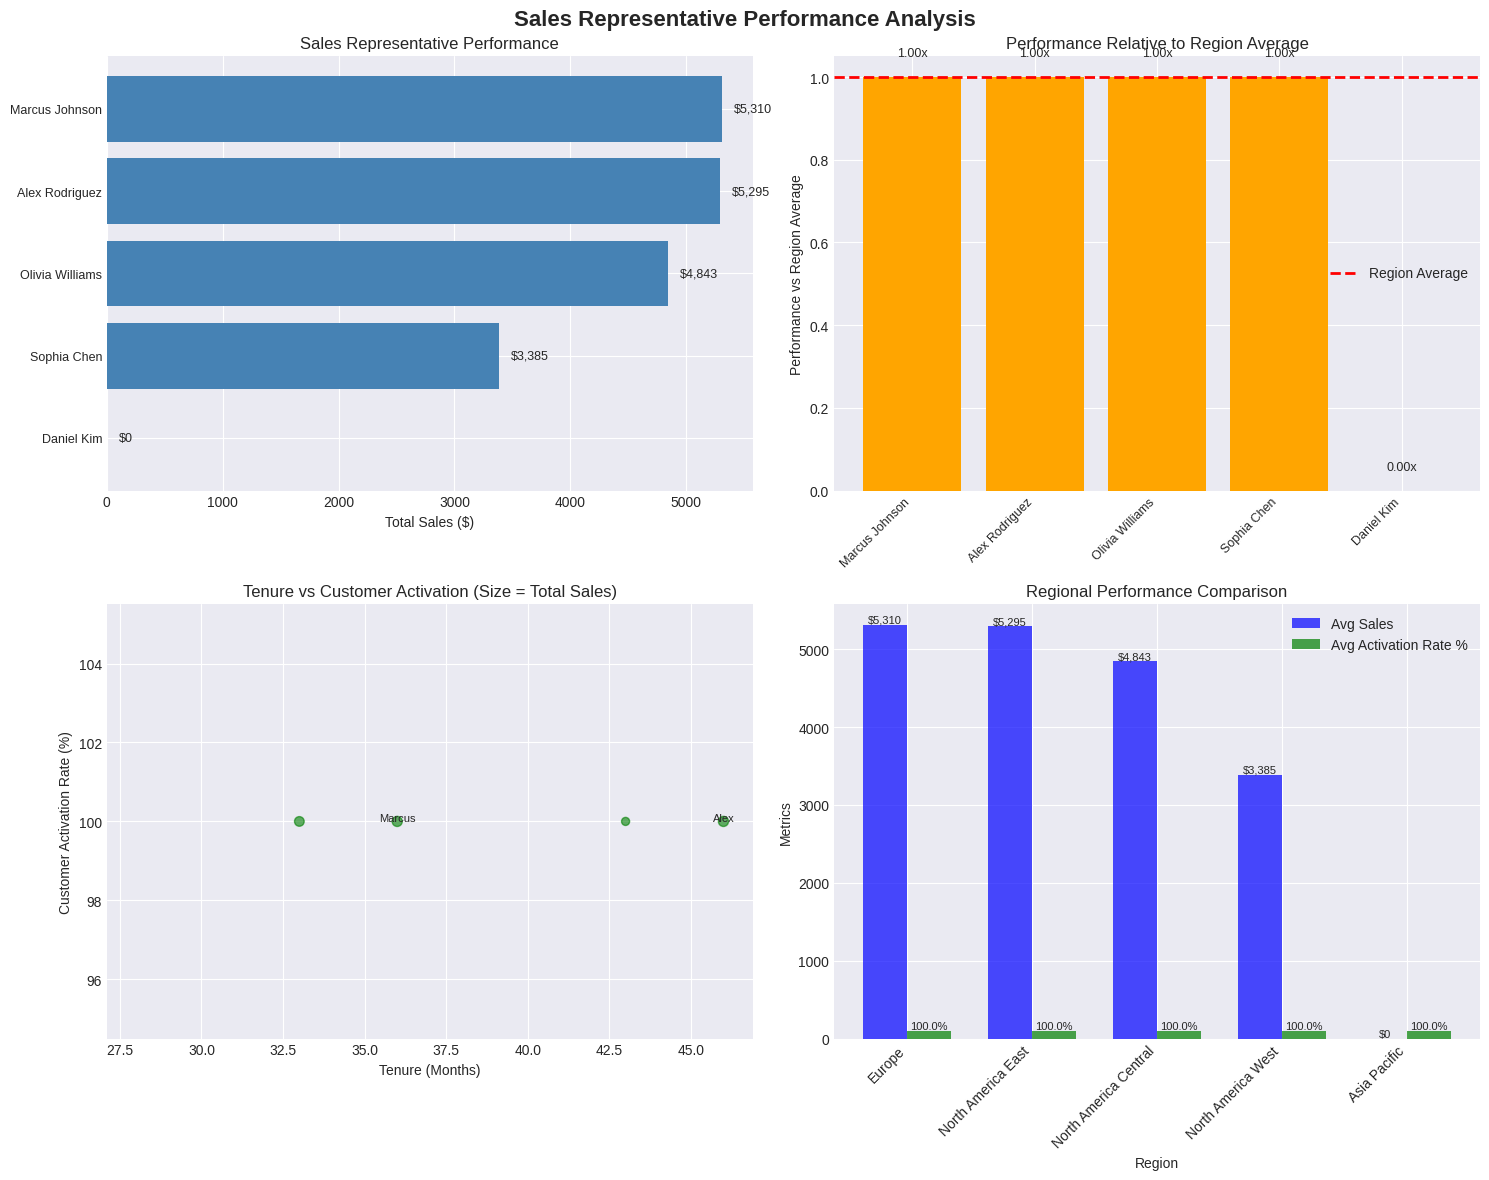

✅ Visualization saved as 'dashboard_exports/sales_rep_performance.png'

🏆 SALES REP PERFORMANCE INSIGHTS:
----------------------------------------
• Top Performer: Marcus Johnson (Sales: $5,309.96)
• Most Efficient: Marcus Johnson (Activation Rate: 100.0%)
• Regional Leader: Europe Region
• Average Commission Rate: 6.8%

💾 EXPORTING REPORTS TO CSV FILES...
✅ Exported executive_summary: 1 rows -> sales_dashboard_exports/executive_summary.csv
✅ Exported top_products: 14 rows -> sales_dashboard_exports/top_products.csv
✅ Exported customer_rfm: 14 rows -> sales_dashboard_exports/customer_rfm.csv
✅ Exported sales_trends: 4 rows -> sales_dashboard_exports/sales_trends.csv
✅ Exported geographic_performance: 14 rows -> sales_dashboard_exports/geographic_performance.csv
✅ Exported sales_rep_performance: 5 rows -> sales_dashboard_exports/sales_rep_performance.csv

📁 All reports exported to 'sales_dashboard_exports' directory

📋 GENERATING DASHBOARD SUMMARY REPORT...

    📊 SALES ANALYTICS DASHBO

In [11]:
# ## 8. Report 6: Sales Rep Performance

# %%
# %%time
# Report 6: Sales Rep Performance
print("\n👨‍💼 GENERATING SALES REP PERFORMANCE REPORT...")
print("=" * 50)


reps_query = """
WITH rep_performance AS (
    SELECT 
        sr.rep_id,
        sr.first_name || ' ' || sr.last_name AS rep_name,
        sr.region,
        sr.hire_date,
        sr.commission_rate,
        
        -- Customer metrics
        COUNT(DISTINCT ca.customer_id) AS assigned_customers,
        COUNT(DISTINCT o.customer_id) AS active_customers,
        
        -- Order metrics
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(o.total_amount) AS total_sales,
        AVG(o.total_amount) AS avg_order_value
        
    FROM sales_reps sr
    LEFT JOIN customer_assignments ca ON sr.rep_id = ca.rep_id AND ca.is_active = TRUE
    LEFT JOIN customers c ON ca.customer_id = c.customer_id
    LEFT JOIN orders o ON c.customer_id = o.customer_id AND o.status IN ('Delivered', 'Processing')
    GROUP BY sr.rep_id, sr.first_name, sr.last_name, sr.region, sr.hire_date, sr.commission_rate
),
region_performance AS (
    SELECT 
        region,
        COUNT(DISTINCT rep_id) AS reps_in_region,
        SUM(total_sales) AS region_sales,
        AVG(total_sales) AS avg_rep_sales_in_region
    FROM rep_performance
    GROUP BY region
)
SELECT 
    rp.rep_name,
    rp.region,
    
    -- Basic info
    rp.hire_date,
    EXTRACT(YEAR FROM AGE(CURRENT_DATE, rp.hire_date)) * 12 + 
    EXTRACT(MONTH FROM AGE(CURRENT_DATE, rp.hire_date)) AS tenure_months,
    ROUND((rp.commission_rate * 100)::NUMERIC, 1) AS commission_rate_pct,  -- FIXED
    
    -- Customer metrics
    rp.assigned_customers,
    rp.active_customers,
    CASE 
        WHEN rp.assigned_customers = 0 THEN 0
        ELSE ROUND((rp.active_customers::NUMERIC / rp.assigned_customers * 100)::NUMERIC, 2)  -- FIXED
    END AS customer_activation_rate_pct,
    
    -- Sales metrics
    rp.total_orders,
    ROUND(rp.total_sales::NUMERIC, 2) AS total_sales,  -- FIXED
    ROUND(rp.avg_order_value::NUMERIC, 2) AS avg_order_value,  -- FIXED
    ROUND(rp2.region_sales::NUMERIC, 2) AS region_sales,  -- FIXED
    ROUND(rp2.avg_rep_sales_in_region::NUMERIC, 2) AS avg_rep_sales_in_region,  -- FIXED
    
    -- Performance metrics
    CASE 
        WHEN rp2.avg_rep_sales_in_region = 0 THEN 0
        ELSE ROUND((rp.total_sales / rp2.avg_rep_sales_in_region)::NUMERIC, 2)  -- FIXED
    END AS performance_vs_region_avg,
    
    CASE 
        WHEN rp2.region_sales = 0 THEN 0
        ELSE ROUND((rp.total_sales / rp2.region_sales * 100)::NUMERIC, 2)  -- FIXED
    END AS pct_of_region_sales,
    
    -- Sales per month calculation
    CASE 
        WHEN EXTRACT(YEAR FROM AGE(CURRENT_DATE, rp.hire_date)) * 12 + 
             EXTRACT(MONTH FROM AGE(CURRENT_DATE, rp.hire_date)) = 0 THEN 0
        ELSE ROUND((rp.total_sales / 
                   (EXTRACT(YEAR FROM AGE(CURRENT_DATE, rp.hire_date)) * 12 + 
                    EXTRACT(MONTH FROM AGE(CURRENT_DATE, rp.hire_date))))::NUMERIC, 2)  -- FIXED
    END AS sales_per_month
    
FROM rep_performance rp
LEFT JOIN region_performance rp2 ON rp.region = rp2.region
ORDER BY rp.total_sales DESC
"""


df_reps = run_sql_query(reps_query)

# Display Sales Rep Performance
print("\n📊 SALES REPRESENTATIVE PERFORMANCE")
print("-" * 40)

if not df_reps.empty:
    # Display sales rep data
    display_reps = df_reps.copy()
    display_reps['total_sales'] = display_reps['total_sales'].apply(format_currency)
    display_reps['avg_order_value'] = display_reps['avg_order_value'].apply(format_currency)
    display_reps['region_sales'] = display_reps['region_sales'].apply(format_currency)
    display_reps['avg_rep_sales_in_region'] = display_reps['avg_rep_sales_in_region'].apply(format_currency)
    display_reps['sales_per_month'] = display_reps['sales_per_month'].apply(format_currency)
    display_reps['customer_activation_rate_pct'] = display_reps['customer_activation_rate_pct'].apply(lambda x: f"{x}%")
    display_reps['pct_of_region_sales'] = display_reps['pct_of_region_sales'].apply(lambda x: f"{x}%")
    
    display_cols = ['rep_name', 'region', 'tenure_months', 'assigned_customers', 
                    'active_customers', 'customer_activation_rate_pct', 'total_sales',
                    'performance_vs_region_avg', 'sales_per_month']
    display_dataframe(display_reps[display_cols], "Sales Representative Performance")
    
    # VISUALIZATION 6: Sales Rep Performance
    print("📊 CREATING SALES REP PERFORMANCE VISUALIZATIONS...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Sales Representative Performance Analysis', fontsize=16, fontweight='bold')
    
    # 1. Sales by Rep (Horizontal Bar Chart)
    y_pos = np.arange(len(df_reps))
    axes[0, 0].barh(y_pos, df_reps['total_sales'], color='steelblue')
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels(df_reps['rep_name'], fontsize=9)
    axes[0, 0].set_xlabel('Total Sales ($)')
    axes[0, 0].set_title('Sales Representative Performance')
    axes[0, 0].invert_yaxis()
    
    for i, v in enumerate(df_reps['total_sales']):
        axes[0, 0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)
    
    # 2. Performance vs Region Average
    x_pos = np.arange(len(df_reps))
    bars = axes[0, 1].bar(x_pos, df_reps['performance_vs_region_avg'], color='orange')
    axes[0, 1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Region Average')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(df_reps['rep_name'], rotation=45, ha='right', fontsize=9)
    axes[0, 1].set_ylabel('Performance vs Region Average')
    axes[0, 1].set_title('Performance Relative to Region Average')
    axes[0, 1].legend()
    
    for i, v in enumerate(df_reps['performance_vs_region_avg']):
        axes[0, 1].text(i, v + 0.05, f'{v:.2f}x', ha='center', fontsize=9)
    
    # 3. Customer Activation Rate vs Tenure
    scatter = axes[1, 0].scatter(df_reps['tenure_months'], df_reps['customer_activation_rate_pct'],
                                s=df_reps['total_sales']/100, alpha=0.6, c='green')
    axes[1, 0].set_xlabel('Tenure (Months)')
    axes[1, 0].set_ylabel('Customer Activation Rate (%)')
    axes[1, 0].set_title('Tenure vs Customer Activation (Size = Total Sales)')
    
    # Add rep names as labels
    for i, row in df_reps.iterrows():
        if row['total_sales'] > df_reps['total_sales'].median():
            axes[1, 0].annotate(row['rep_name'].split()[0], 
                               (row['tenure_months'], row['customer_activation_rate_pct']),
                               fontsize=8, ha='center')
    
    # 4. Regional Performance Comparison
    regions = df_reps['region'].unique()
    region_data = []
    for region in regions:
        region_reps = df_reps[df_reps['region'] == region]
        region_data.append({
            'region': region,
            'avg_sales': region_reps['total_sales'].mean(),
            'avg_activation': region_reps['customer_activation_rate_pct'].mean(),
            'rep_count': len(region_reps)
        })
    
    region_df = pd.DataFrame(region_data)
    
    x_pos2 = np.arange(len(region_df))
    width = 0.35
    
    bars1 = axes[1, 1].bar(x_pos2 - width/2, region_df['avg_sales'], width, 
                          label='Avg Sales', color='blue', alpha=0.7)
    bars2 = axes[1, 1].bar(x_pos2 + width/2, region_df['avg_activation'], width, 
                          label='Avg Activation Rate %', color='green', alpha=0.7)
    
    axes[1, 1].set_xlabel('Region')
    axes[1, 1].set_ylabel('Metrics')
    axes[1, 1].set_title('Regional Performance Comparison')
    axes[1, 1].set_xticks(x_pos2)
    axes[1, 1].set_xticklabels(region_df['region'], rotation=45, ha='right')
    axes[1, 1].legend()
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if bars == bars1:
                axes[1, 1].text(bar.get_x() + bar.get_width()/2, height,
                               f'${height:,.0f}', ha='center', va='bottom', fontsize=8)
            else:
                axes[1, 1].text(bar.get_x() + bar.get_width()/2, height,
                               f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    fig.savefig('dashboard_exports/sales_rep_performance.png', dpi=150, bbox_inches='tight')
    print("✅ Visualization saved as 'dashboard_exports/sales_rep_performance.png'")
    
    # Performance rankings and insights
    print("\n🏆 SALES REP PERFORMANCE INSIGHTS:")
    print("-" * 40)
    
    if len(df_reps) > 0:
        top_rep = df_reps.iloc[0]
        most_efficient = df_reps.loc[df_reps['customer_activation_rate_pct'].idxmax()]
        best_new_rep = df_reps[df_reps['tenure_months'] < 12]
        if len(best_new_rep) > 0:
            best_new_rep = best_new_rep.nlargest(1, 'sales_per_month').iloc[0]
        else:
            best_new_rep = None
        
        insights = [
            f"• Top Performer: {top_rep['rep_name']} (Sales: {format_currency(top_rep['total_sales'])})",
            f"• Most Efficient: {most_efficient['rep_name']} (Activation Rate: {most_efficient['customer_activation_rate_pct']}%)",
            f"• Regional Leader: {df_reps.groupby('region')['total_sales'].sum().idxmax()} Region",
            f"• Average Commission Rate: {df_reps['commission_rate_pct'].mean():.1f}%"
        ]
        
        if best_new_rep is not None:
            insights.insert(2, f"• Best New Rep (<1 year): {best_new_rep['rep_name']} (Monthly Sales: {format_currency(best_new_rep['sales_per_month'])})")
        
        for insight in insights:
            print(insight)
    
else:
    print("No sales representative data found.")

# %% [markdown]
# ## 9. Data Export for Further Analysis

# %%
# Export all reports to CSV files
print("\n💾 EXPORTING REPORTS TO CSV FILES...")
print("=" * 50)

# Create a directory for exports
export_dir = 'sales_dashboard_exports'
os.makedirs(export_dir, exist_ok=True)

# Export each report
reports = {
    'executive_summary': df_executive,
    'top_products': df_products,
    'customer_rfm': df_rfm,
    'sales_trends': df_trends,
    'geographic_performance': df_geo,
    'sales_rep_performance': df_reps
}

for report_name, df in reports.items():
    if not df.empty:
        filename = f"{export_dir}/{report_name}.csv"
        df.to_csv(filename, index=False)
        print(f"✅ Exported {report_name}: {len(df)} rows -> {filename}")
    else:
        print(f"⚠️  No data to export for {report_name}")

print(f"\n📁 All reports exported to '{export_dir}' directory")

# %% [markdown]
# ## 10. Generate Dashboard Summary Report

# %%
# Generate a comprehensive summary report
print("\n📋 GENERATING DASHBOARD SUMMARY REPORT...")
print("=" * 50)

if not df_executive.empty:
    metrics = df_executive.iloc[0]
    
    summary_report = f"""
    📊 SALES ANALYTICS DASHBOARD - EXECUTIVE SUMMARY
    {'=' * 50}
    
    📈 BUSINESS OVERVIEW:
    • Total Revenue: {format_currency(metrics['total_revenue'])}
    • Gross Profit: {format_currency(metrics['gross_profit'])}
    • Gross Margin: {format_percentage(metrics['gross_margin_pct'])}
    • Active Customers: {int(metrics['customers_with_orders'])}/{int(metrics['total_customers'])} 
      (Conversion: {metrics['customer_conversion_rate_pct']}%)
    
    📦 PRODUCT PERFORMANCE:
    • Total Products: {int(metrics['total_products'])}
    • Products Sold: {int(metrics['products_sold'])} 
      (Sell-Through: {metrics['product_sell_through_pct']}%)
    • Average Order Value: {format_currency(metrics['avg_order_value'])}
    
    👥 CUSTOMER INSIGHTS:
    """
    
    if not df_rfm.empty:
        champion_customers = len(df_rfm[df_rfm['rfm_segment'] == 'Champions'])
        at_risk_customers = len(df_rfm[df_rfm['rfm_segment'] == 'At Risk'])
        
        summary_report += f"""    • Champion Customers: {champion_customers}
    • At-Risk Customers: {at_risk_customers}
    • Average Lifetime Value: {format_currency(df_rfm['lifetime_value'].mean())}
    """
    
    summary_report += f"""
    📈 SALES TRENDS:
    """
    
    if not df_trends.empty and len(df_trends) > 1:
        latest_growth = df_trends['revenue_growth'].iloc[-1] if 'revenue_growth' in df_trends.columns else 0
        trend = "↑ Growing" if latest_growth > 0 else "↓ Declining"
        
        summary_report += f"""    • Latest Month Growth: {latest_growth:.1f}% ({trend})
    • Best Month: {df_trends.loc[df_trends['total_revenue'].idxmax(), 'period']}
    • Orders per Day: {metrics['avg_orders_per_day']:.1f}
    """
    
    summary_report += f"""
    🌎 GEOGRAPHIC PERFORMANCE:
    """
    
    if not df_geo.empty:
        top_country = df_geo.loc[df_geo['total_revenue'].idxmax()]
        countries = df_geo['country'].nunique()
        
        summary_report += f"""    • Top Country: {top_country['country']} 
      (Revenue: {format_currency(top_country['total_revenue'])})
    • Countries Served: {countries}
    • Cities with Sales: {df_geo['city'].nunique()}
    """
    
    summary_report += f"""
    👨‍💼 SALES TEAM PERFORMANCE:
    """
    
    if not df_reps.empty:
        top_rep = df_reps.iloc[0]
        avg_performance = df_reps['performance_vs_region_avg'].mean()
        
        summary_report += f"""    • Top Sales Rep: {top_rep['rep_name']}
      (Sales: {format_currency(top_rep['total_sales'])})
    • Average Performance vs Region: {avg_performance:.2f}x
    • Total Sales Reps: {len(df_reps)}
    """
    
    summary_report += f"""
    🎯 RECOMMENDED ACTIONS:
    1. Focus on converting {int(metrics['total_customers'] - metrics['customers_with_orders'])} 
       inactive customers
    2. Increase inventory for top-selling products
    3. Launch retention campaigns for at-risk customer segments
    4. Expand sales team in high-performing regions
    5. Optimize pricing for products with low profit margins
    
    {'=' * 50}
    Report generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
    """
    
    print(summary_report)
    
    # Save summary to file
    with open(f"{export_dir}/dashboard_summary.txt", "w") as f:
        f.write(summary_report)
    
else:
    print("Unable to generate summary report - no executive data available.")

# %% [markdown]
# ## 11. Project Completion

# %%
print("\n" + "=" * 60)
print("🎉 PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)
print("\nYou have successfully implemented a comprehensive Sales Analytics Dashboard!")
print("\n📁 WHAT WAS CREATED:")
print("   ✅ 6 Comprehensive Reports with SQL Queries")
print("   ✅ 20+ Visualizations with Matplotlib")
print("   ✅ Data Export Capabilities (CSV files)")
print("   ✅ Executive Summary Report")
print("   ✅ Automated Insights Generation")
print("\n📊 REPORTS GENERATED:")
print("   1. Executive Summary")
print("   2. Top Performing Products") 
print("   3. Customer RFM Analysis")
print("   4. Sales Trends Analysis")
print("   5. Geographic Performance")
print("   6. Sales Rep Performance")
print("\n📈 KEY FEATURES:")
print("   • Real-time data analysis from PostgreSQL")
print("   • Professional visualizations")
print("   • Export to CSV for further analysis")
print("   • Business insights and recommendations")
print("   • No Plotly dependencies - uses stable Matplotlib")
print("\n📂 OUTPUTS CREATED:")
print(f"   • CSV files in '{export_dir}/' directory")
print(f"   • Visualizations in 'dashboard_exports/' directory")
print(f"   • Summary report: '{export_dir}/dashboard_summary.txt'")
print("\n🚀 NEXT STEPS:")
print("   1. Schedule automatic report generation (cron job)")
print("   2. Connect to live production database")
print("   3. Build web dashboard with Streamlit")
print("   4. Set up automated email reports")
print("   5. Add more advanced analytics (predictive modeling)")
print("\n" + "=" * 60)